In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]




/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [32]:

example_NDNF_cell = fixed_activity_dict_NDNF_newest['animal_19']["cell_2"]

example_NDNF_cell_tensor = torch.from_numpy(example_NDNF_cell).unsqueeze(axis=1)
example_NDNF_cell_tensor = example_NDNF_cell_tensor.permute(2, 1, 0)
print(example_NDNF_cell_tensor.shape)  # should now be torch.Size([78, 1, 50])

components_10, model_10_NDNF = slicetca.decompose(example_NDNF_cell_tensor,
                                       number_components=(0,0,10), # (trials, neurons, time bins)
                                       positive=False,
                                       learning_rate=1*10**-3,
                                       min_std=10**-5,
                                       max_iter=15_000,
                                       seed=0)




torch.Size([107, 1, 50])


The model converged. Loss: 0.10269248829573181 :  27%|██▋       | 4109/15000 [00:21<00:57, 190.47it/s]


In [77]:

def get_animals_models(fixed_activity_dict_NDNF_newest, animal):
    models_list = []

    for cell in fixed_activity_dict_NDNF_newest[animal]:

        example_NDNF_cell = fixed_activity_dict_NDNF_newest[animal][cell]

        example_NDNF_cell_tensor = torch.from_numpy(example_NDNF_cell).unsqueeze(axis=1)
        example_NDNF_cell_tensor = example_NDNF_cell_tensor.permute(2, 1, 0)
        print(example_NDNF_cell_tensor.shape)  # should now be torch.Size([78, 1, 50])

        components_10, model_10_NDNF = slicetca.decompose(example_NDNF_cell_tensor,
                                            number_components=(0,0,10), # (trials, neurons, time bins)
                                            positive=False,
                                            learning_rate=1*10**-3,
                                            min_std=10**-5,
                                            max_iter=15_000,
                                            seed=0)
        
        models_list.append(model_10_NDNF)
    return models_list


models_dict_per_animal = {}
for animal in fixed_activity_dict_NDNF_newest:
    models_list_animal = get_animals_models(fixed_activity_dict_NDNF_newest, animal)
    models_dict_per_animal[animal] = models_list_animal







torch.Size([107, 1, 50])


The model converged. Loss: 0.10269248829573181 :  27%|██▋       | 4109/15000 [00:16<00:43, 250.58it/s]


torch.Size([107, 1, 50])


The model converged. Loss: 0.08394057887392685 :  35%|███▌      | 5253/15000 [00:22<00:41, 232.76it/s]


torch.Size([107, 1, 50])


...

The model converged. Loss: 0.12306818321608275 :  48%|████▊     | 7155/15000 [00:29<00:32, 240.67it/s]


torch.Size([100, 1, 50])


The model converged. Loss: 0.19460632915604095 :  31%|███       | 4674/15000 [00:21<00:47, 215.15it/s]


torch.Size([100, 1, 50])


The model converged. Loss: 0.17402850879063161 :  33%|███▎      | 4964/15000 [00:21<00:43, 232.70it/s]


In [110]:
models_list = models_dict_per_animal['animal_19']

In [104]:
save_path = '/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/all_ndnf_cells_slicetca_00x.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(models_dict_per_animal, f)
    print(f"saved to {save_path}")

saved to /Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/all_ndnf_cells_slicetca_00x.pkl


In [34]:
fixed_activity_dict_NDNF_newest['animal_19'].keys()

dict_keys(['cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7', 'cell_8'])

w1.shape torch.Size([10, 50])
f1.shape torch.Size([10, 107, 1])


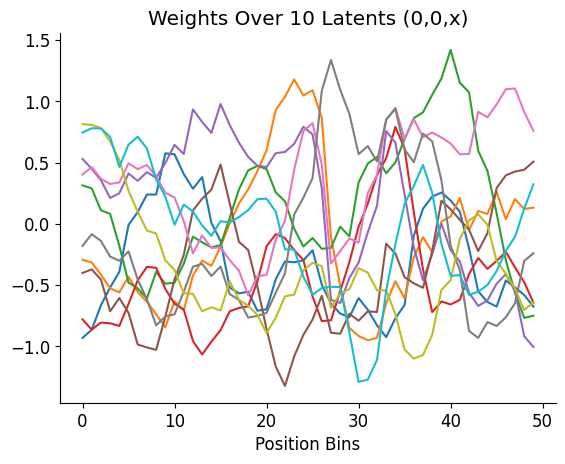

In [ ]:
model = model_10_NDNF

#[0,:]
#[0,0,:]
w1 = model.vectors[2][0].detach()
f1 = model.vectors[2][1].detach()

for i in range(w1.shape[0]):
    plt.plot(w1[i,:])
plt.title("Weights Over 10 Latents (0,0,x)")
plt.xlabel("Position Bins")
plt.show()

# w2 = model.vectors[0][0][1,:].detach()
# f2 = model.vectors[0][1][1,0,:].detach()
# w3 = model.vectors[0][0][2,:].detach()
# f3 = model.vectors[0][1][2,0,:].detach()

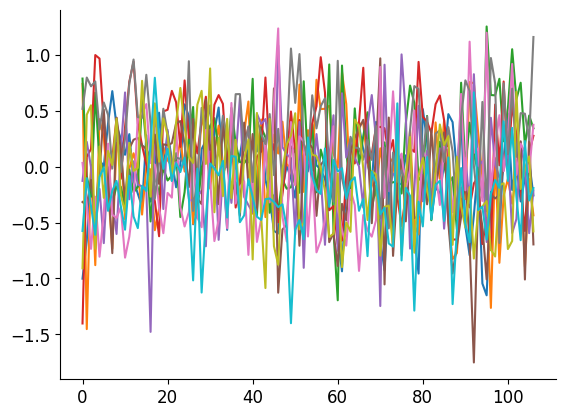

In [38]:
f1.shape

for i in range(f1.shape[0]):
    plt.plot(f1[i,:])
plt.show()

In [49]:
import numpy as np
from sklearn.cluster import KMeans
f1 = model.vectors[2][1]
X = f1.detach().cpu().numpy()   # (10, 107, 1)
X = np.squeeze(X, axis=-1)      # -> (10, 107)

labels_latents = KMeans(n_clusters=3, n_init=50, random_state=0).fit_predict(X)
print(labels_latents)  # length 10



[1 1 0 2 1 1 0 2 1 1]


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


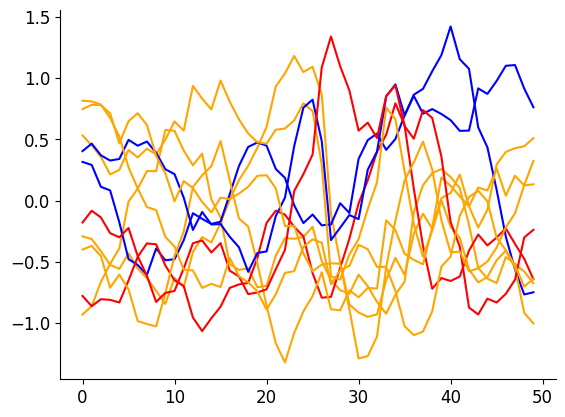

In [ ]:
w1 = model.vectors[2][0].detach()
w1.shape


color_dict = {0:"blue",
              1:"orange",
              2:"red",
}

for label in range(len(labels_latents)):
    color=color_dict[labels_latents[label]]
    plt.plot(w1[label], color=color)
plt.show()







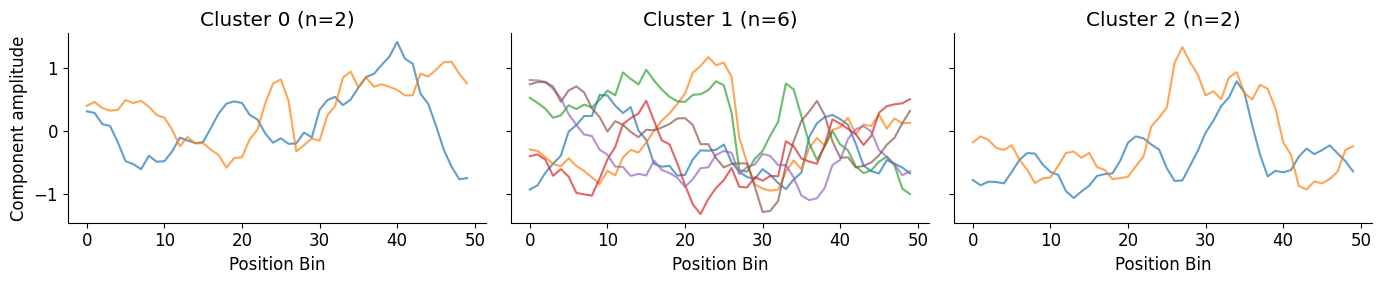

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# w1: (n_latents, T) — transpose if yours is (T, n_latents)
W = w1.detach().cpu().numpy()
labels = np.asarray(labels_latents)
uniq = np.unique(labels)

fig, axes = plt.subplots(1, len(uniq), figsize=(14, 3), sharex=True, sharey=True)
if len(uniq) == 1:
    axes = [axes]

# containers
cluster_latents = {k: [] for k in uniq}     # waveforms per cluster
cluster_indices = {k: [] for k in uniq}     # latent indices per cluster

for ax, (j, k) in zip(axes, enumerate(uniq)):
    idx = np.where(labels == k)[0]          # indices of latents in cluster k
    cluster_indices[k] = idx.tolist()
    for i in idx:
        ax.plot(W[i], alpha=0.7)
        cluster_latents[k].append(W[i].copy())
    ax.set_title(f"Cluster {k} (n={len(idx)})")
    ax.set_xlabel("Position Bin")
axes[0].set_ylabel("Component amplitude")
plt.tight_layout()
plt.show()


In [55]:
labels = np.asarray(labels_latents)         # (n_latents,)
uniq = np.unique(labels)
uniq

array([0, 1, 2], dtype=int32)

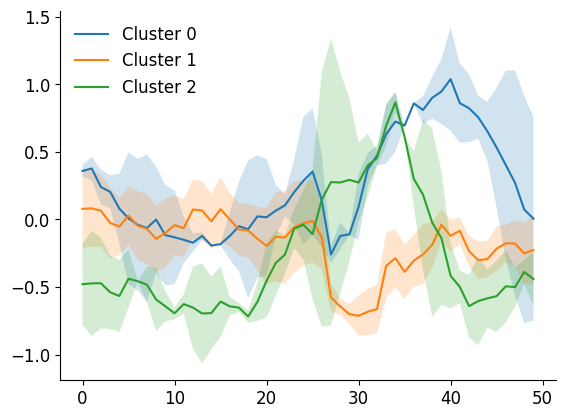

In [63]:
for i in range(len(cluster_latents)):
    cluster = cluster_latents[i]
    cluster_array = np.array(cluster)

    mean_cluster = np.mean(cluster_array, axis=0)
    sem_cluster = sem(cluster_array, axis=0)
    plt.plot(mean_cluster, label=f"Cluster {i}")
    plt.fill_between(range(len(mean_cluster)), mean_cluster-sem_cluster, mean_cluster+sem_cluster, alpha=0.2)
    plt.legend()
plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'plot'

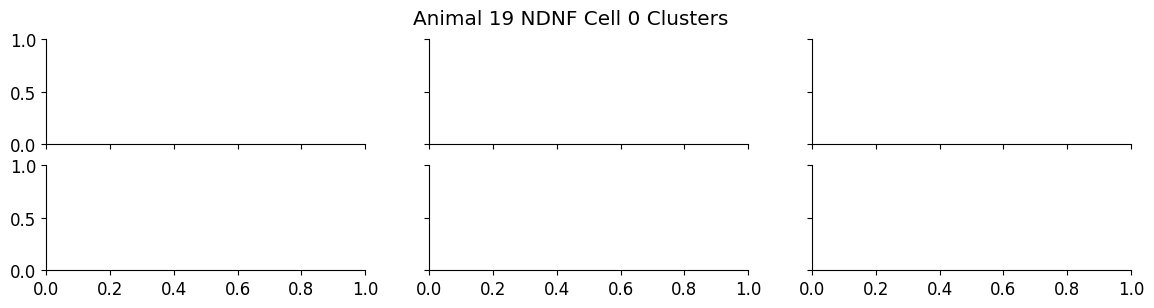

In [114]:
labels_list = []

cluster_latents_per_cell_dict= {}

for model in range(len(models_list)):
    model_cell = models_list[model]
    w1 = model_cell.vectors[2][0].detach()
    W = w1.detach().cpu().numpy()
    f1 = model_cell.vectors[2][1]
    X = f1.detach().cpu().numpy()   # (10, 107, 1)
    X = np.squeeze(X, axis=-1)      # -> (10, 107)
    labels_latents = KMeans(n_clusters=3, n_init=50, random_state=0).fit_predict(X)
    labels_list.append(labels_latents)

    labels = np.asarray(labels_latents)
    uniq = np.unique(labels)

    fig, axes = plt.subplots(2, len(uniq), figsize=(14, 3), sharex=True, sharey=True)
    plt.suptitle(f"Animal 19 NDNF Cell { model } Clusters")
    if len(uniq) == 1:
        axes = [axes]

    # containers
    cluster_latents = {k: [] for k in uniq}     # waveforms per cluster
    cluster_indices = {k: [] for k in uniq}     # latent indices per cluster

    for ax, (j, k) in zip(axes, enumerate(uniq)):
        idx = np.where(labels == k)[0]          # indices of latents in cluster k
        cluster_indices[k] = idx.tolist()
        for i in idx:
            ax.plot(W[i], alpha=0.7)
            cluster_latents[k].append(W[i].copy())
        ax.set_title(f"Cluster {k} (n={len(idx)})")
        ax.set_xlabel("Position Bin")
    axes[0].set_ylabel("Component amplitude")
    cluster_latents_per_cell_dict[model] = cluster_latents
    plt.tight_layout()
    plt.show()


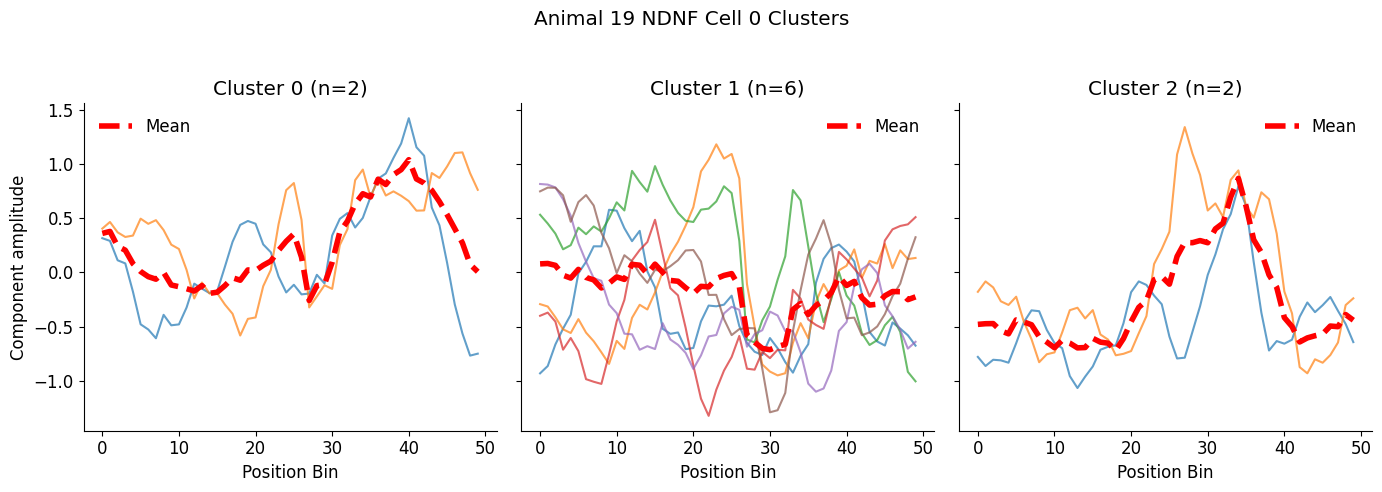

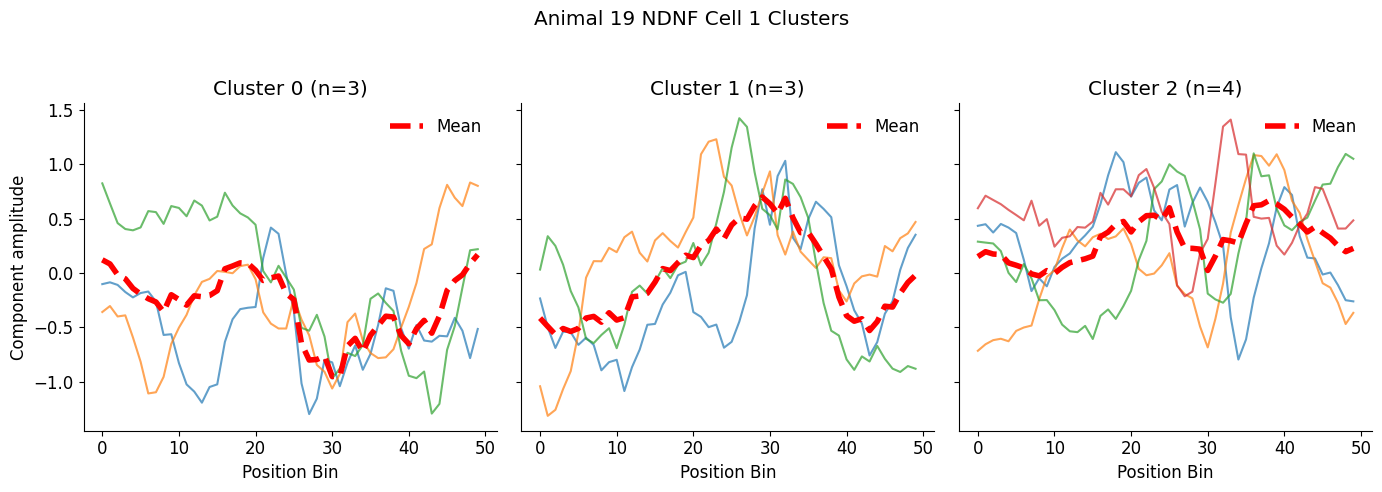

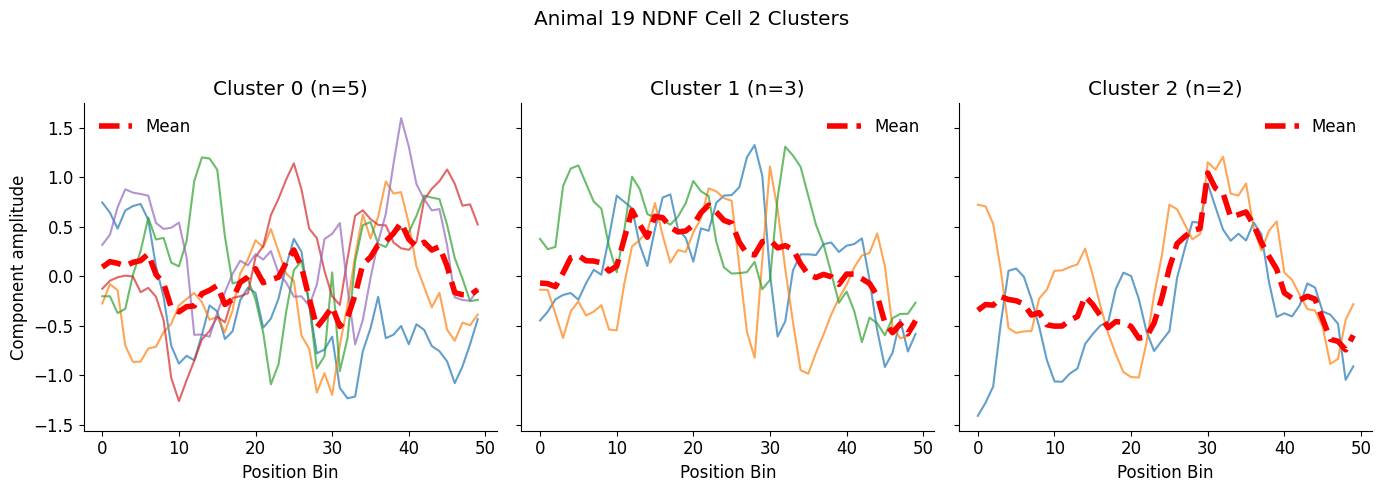

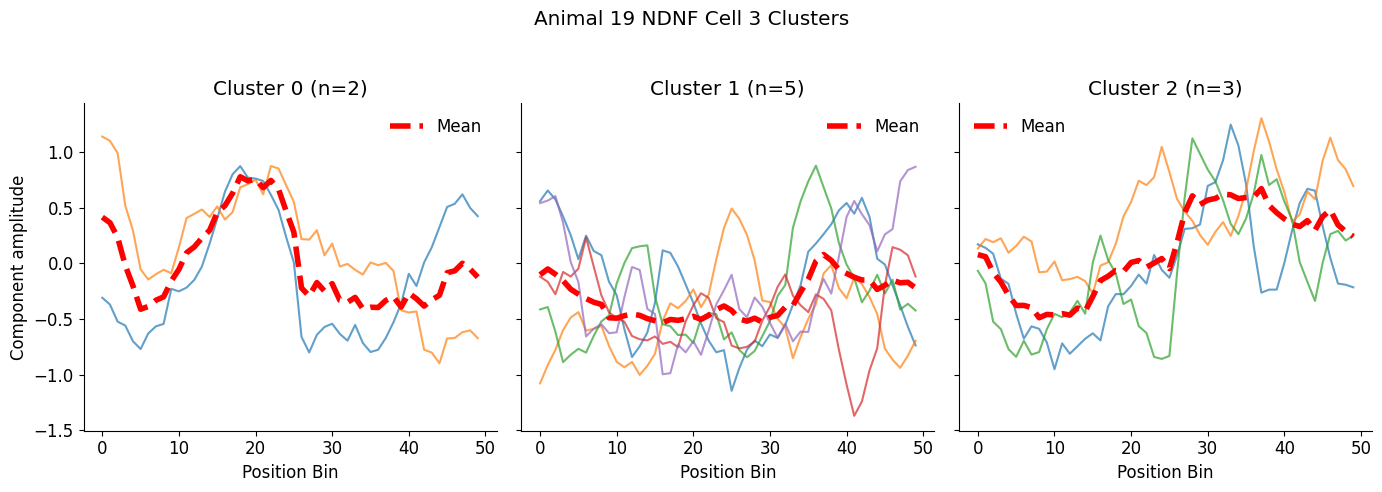

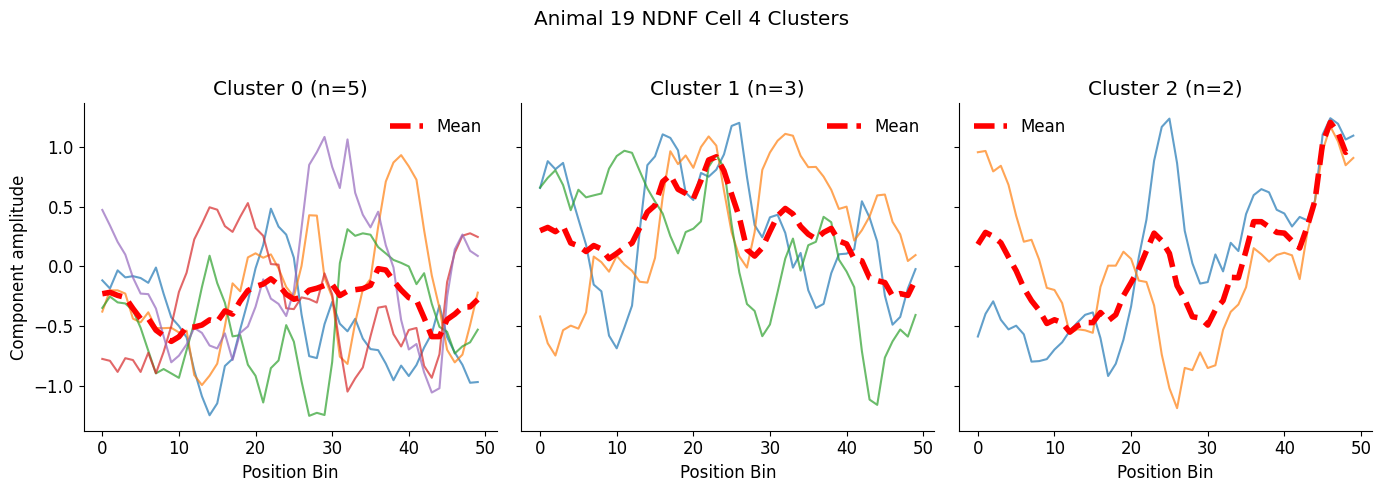

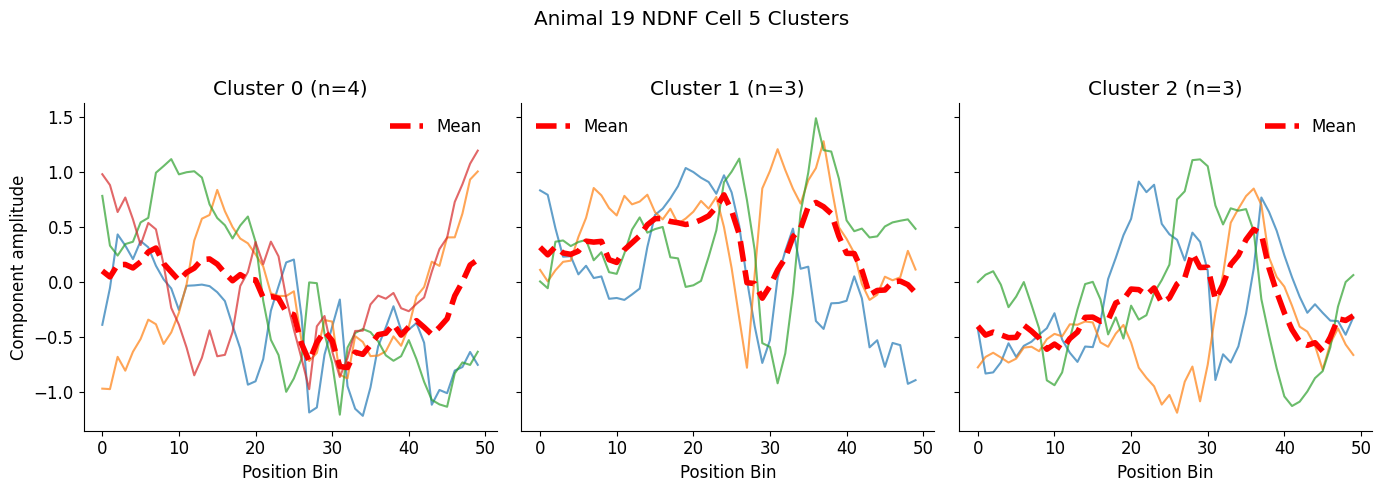

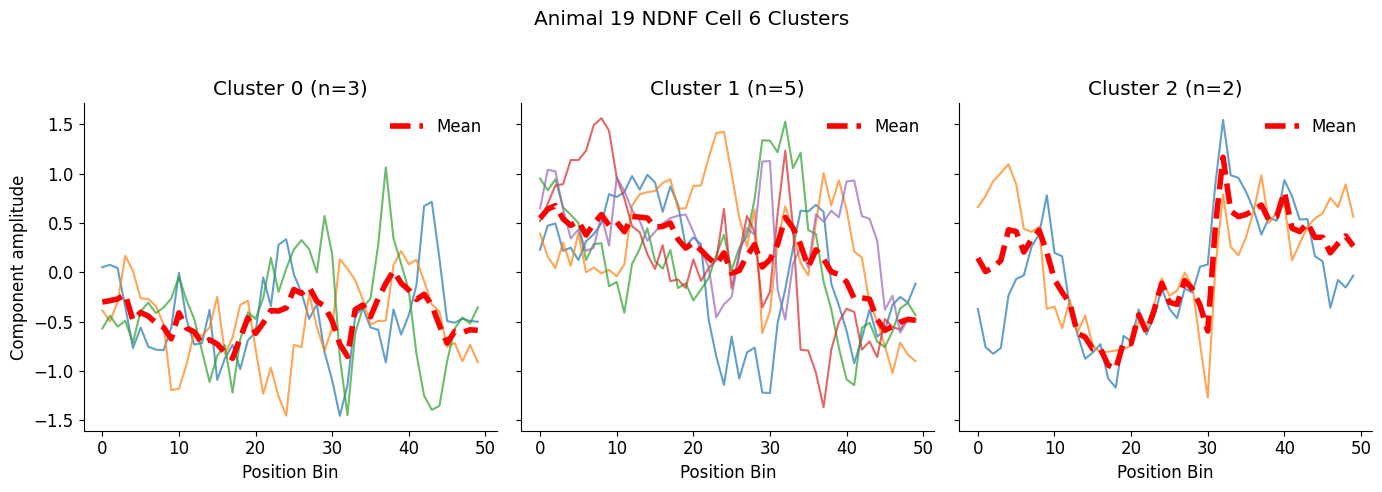

In [125]:
labels_list = []
cluster_latents_per_cell_dict = {}

for model in range(len(models_list)):
    model_cell = models_list[model]

    # tensors -> numpy
    w1 = model_cell.vectors[2][0].detach().cpu().numpy()   # expect (n_latents, n_pos) OR (n_pos, n_latents)
    f1 = model_cell.vectors[2][1].detach().cpu().numpy()   # (10, 107, 1) in your comment
    X = np.squeeze(f1, axis=-1)                            # -> (10, 107)

    # KMeans expects (n_samples, n_features)
    labels_latents = KMeans(n_clusters=3, n_init=50, random_state=0).fit_predict(X)
    labels_list.append(labels_latents)

    labels = np.asarray(labels_latents)
    uniq = np.unique(labels)

    # ----- plotting -----
    ncols = len(uniq)
    fig, axes = plt.subplots(1, ncols, figsize=(14, 5), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)   # ensures 1-D array even when ncols == 1
    fig.suptitle(f"Animal 19 NDNF Cell {model} Clusters")

    # containers
    cluster_latents = {k: [] for k in uniq}     # waveforms per cluster
    cluster_indices = {k: [] for k in uniq}     # latent indices per cluster

    # If w1 is (n_pos, n_latents), transpose so W[i] is a waveform for latent i
    W = w1
    if W.ndim == 2 and W.shape[0] != X.shape[0] and W.shape[1] == X.shape[0]:
        W = W.T  # make it (n_latents, n_pos)

    for ax, k in zip(axes, uniq):
        idx = np.where(labels == k)[0]          # indices of latents in cluster k
        cluster_indices[k] = idx.tolist()
        list_means = []
        for i in idx:
            ax.plot(W[i], alpha=0.7)
            list_means.append(W[i])
            cluster_latents[k].append(W[i].copy())
        list_array = np.array(list_means)
        mean_list_array = np.mean(list_means, axis=0)
        ax.plot(mean_list_array, linewidth=4, linestyle='--', label='Mean', color='r')
        ax.set_title(f"Cluster {k} (n={len(idx)})")
        ax.set_xlabel("Position Bin")
        ax.legend()

    axes[0].set_ylabel("Component amplitude")
    cluster_latents_per_cell_dict[model] = cluster_latents

    fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave room for suptitle
    plt.show()


In [69]:

list_mean_waveforms = []
mean_waveforms_dict_cell = {}
for cell in cluster_latents_per_cell_dict:
    cells_clusters = cluster_latents_per_cell_dict[cell]
    mean_waveform_dict = {}
    for key in cells_clusters:
        cells_clusters_array = np.array(cells_clusters[key])
        cluster_mean_waveform = np.mean(cells_clusters_array, axis=0)
        mean_waveform_dict[key] = cluster_mean_waveform
        
        list_mean_waveforms.append(cluster_mean_waveform)
    mean_waveforms_dict_cell[cell] = mean_waveform_dict


In [124]:
from scipy.stats import sem
import numpy as np
import matplotlib.pyplot as plt


def get_cluster_averages_all_cells(models_dict_per_animal, plot=False):
    clusters_per_animal_dict = {}

    mean_clust_list = []

    for animal in models_dict_per_animal:
        models_list = models_dict_per_animal[animal]

        for model in range(len(models_list)):
            model_cell = models_list[model]
            w1 = model_cell.vectors[2][0]
            f1 = model_cell.vectors[2][1]
            X = f1.detach().cpu().numpy()   # (10, 107, 1)
            X = np.squeeze(X, axis=-1)      # -> (10, 107)
            # W: (n_latents, T) as numpy
            W = w1.detach().cpu().numpy()
            W = np.asarray(W)

            labels_latents = KMeans(n_clusters=3, n_init=50, random_state=0).fit_predict(X)
            labels = np.asarray(labels_latents)
            uniq = np.unique(labels)

            if plot:
                fig, axes = plt.subplots(2, len(uniq), figsize=(14, 8), sharex=True, sharey='row')
                plt.suptitle(f"Animal 19 NDNF Cell {model} Clusters")

                # ensure axes is shape (2, n_clusters)
                if len(uniq) == 1:
                    axes = np.array(axes).reshape(2, 1)

                cluster_latents = {k: [] for k in uniq}   # optional: keep waveforms
                cluster_indices = {k: [] for k in uniq}   # optional: keep latent ids

                for j, k in enumerate(uniq):
                    ax_top = axes[0, j]
                    ax_bot = axes[1, j]

                    idx = np.where(labels == k)[0]
                    cluster_indices[k] = idx.tolist()

                    # top: plot all latents in this cluster
                    for i in idx:
                        ax_top.plot(W[i], alpha=0.7)
                        cluster_latents[k].append(W[i].copy())

                    # bottom: mean ± SEM of cluster waveforms
                    if idx.size:
                        arr = W[idx]                        # (n_in_cluster, T)
                        mean_clust = arr.mean(axis=0)
                        sem_clust  = sem(arr, axis=0)
                        mean_clust_list.append(mean_clust)

                        ax_bot.plot(mean_clust, linewidth=2)
                        ax_bot.fill_between(
                            np.arange(mean_clust.size),
                            mean_clust + sem_clust,
                            mean_clust - sem_clust,
                            alpha=0.2
                        )

                    ax_top.set_title(f"Cluster {k} (n={idx.size})")
                    ax_bot.set_xlabel("Position Bin")

                axes[0, 0].set_ylabel("Component amplitude")
                axes[1, 0].set_ylabel("Mean ± SEM")

                plt.tight_layout()
                plt.show()
            else:

                cluster_latents = {k: [] for k in uniq}   # optional: keep waveforms
                cluster_indices = {k: [] for k in uniq}   # optional: keep latent ids
                for j, k in enumerate(uniq):
                    
                    idx = np.where(labels == k)[0]
                    cluster_indices[k] = idx.tolist()

                    # top: plot all latents in this cluster
                    for i in idx:
                        cluster_latents[k].append(W[i].copy())

                    # bottom: mean ± SEM of cluster waveforms
                    if idx.size:
                        arr = W[idx]                        # (n_in_cluster, T)
                        mean_clust = arr.mean(axis=0)
                        mean_clust_list.append(mean_clust)

        

        clusters_per_animal_dict[animal] = mean_clust_list
    return clusters_per_animal_dict, mean_clust_list

            
clusters_per_animal_dict, mean_clust_list = get_cluster_averages_all_cells(models_dict_per_animal, plot=False)

print(len(mean_clust_list))

# If you want to keep per-cell:
# cluster_latents_per_cell_dict[model] = cluster_latents


345


total len 345 vs computed 345


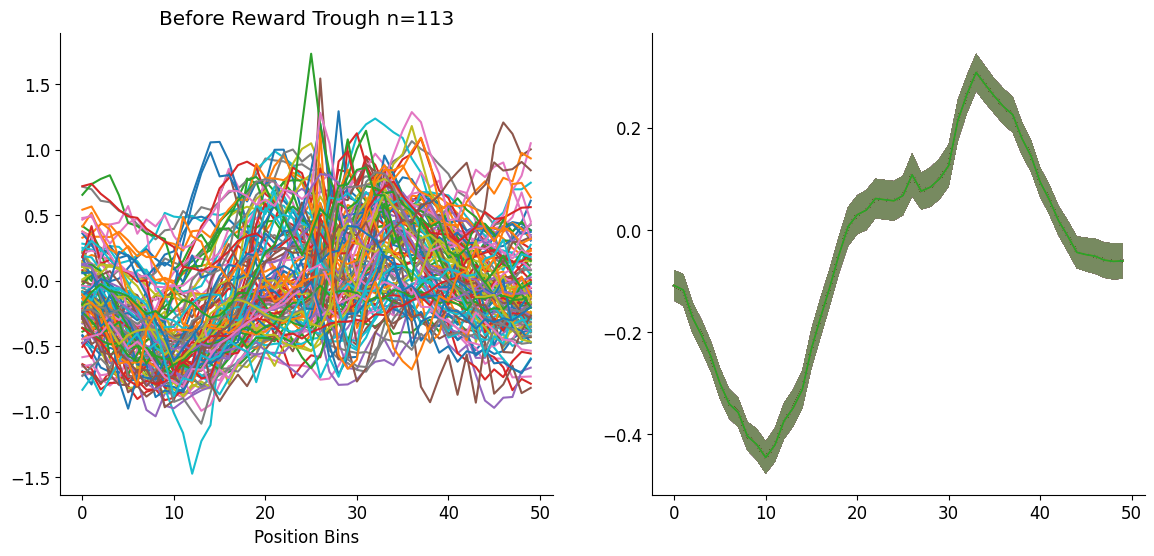

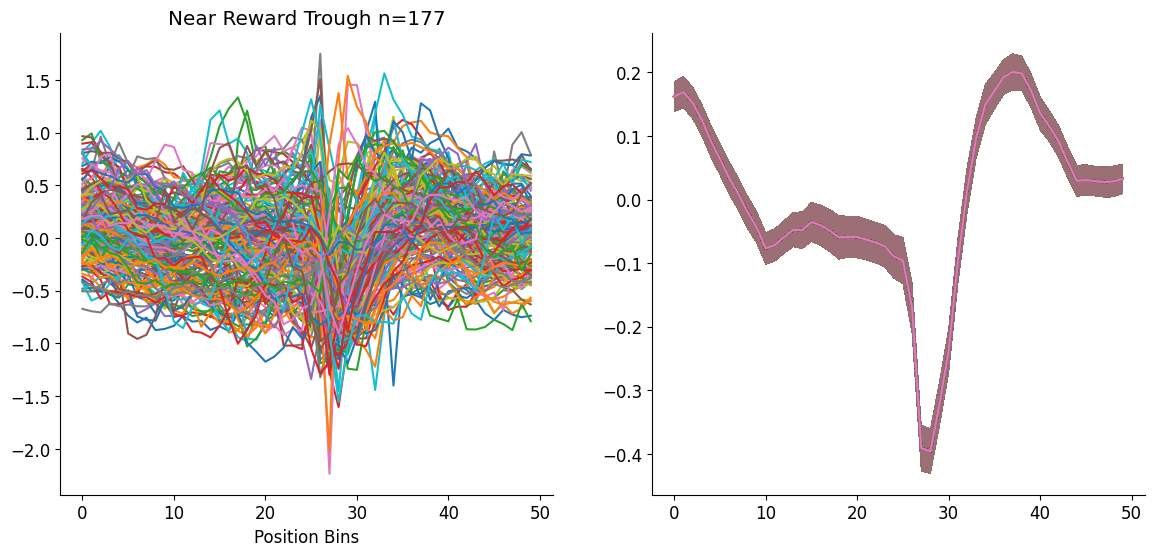

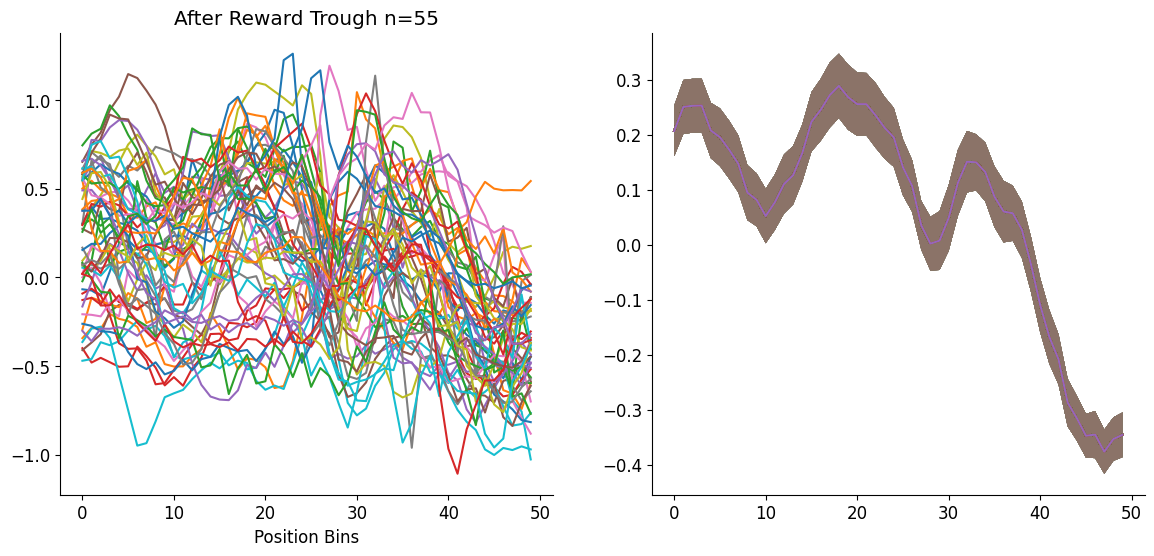

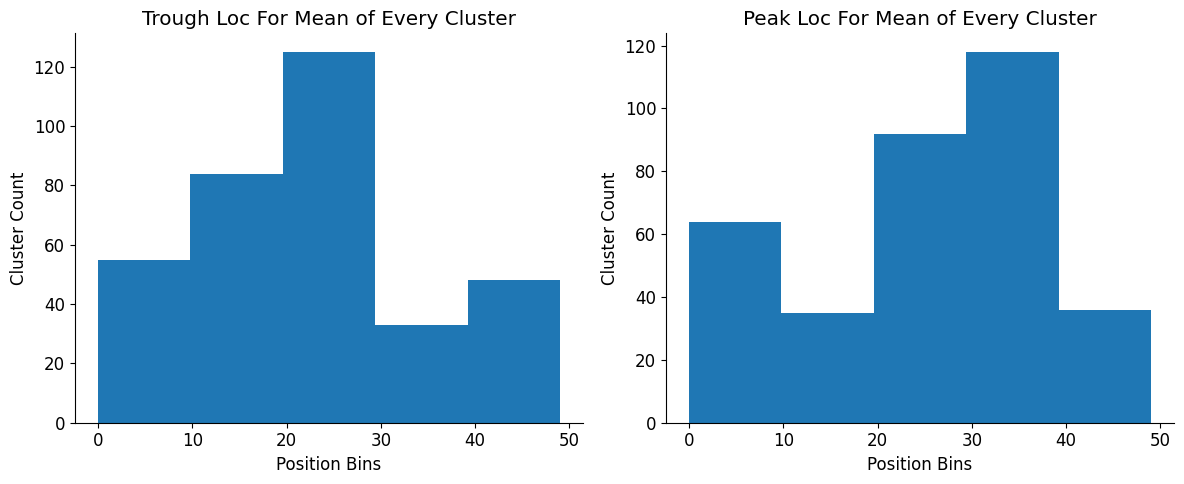

In [129]:

############## using the mean cluster list 

before_reward = []
near_reward = []
after_reward = []


min_value_list = []
max_value_list = []

for i in range(len(mean_clust_list)):
    data = mean_clust_list[i]

    min_value = np.argmin(data)
    min_value_list.append(min_value)
    max_value = np.argmax(data)
    max_value_list.append(max_value)
    if min_value <=15:
        before_reward.append(data)
    elif 15 < min_value <35:
        near_reward.append(data)
    elif min_value >=35:
        after_reward.append(data)

print(f"total len {len(mean_clust_list)} vs computed {len(before_reward) + len(near_reward) + len(after_reward)}")


before_reward_array=np.array(before_reward)
mean_before_reward_array = np.mean(before_reward_array, axis=0)
sem_before_reward_array = sem(before_reward_array, axis=0)

near_reward_array=np.array(near_reward)
mean_near_reward_array = np.mean(near_reward_array, axis=0)
sem_near_reward_array = sem(near_reward_array, axis=0)

after_reward_array=np.array(after_reward)
mean_after_reward_array = np.mean(after_reward_array, axis=0)
sem_after_reward_array = sem(after_reward_array, axis=0)

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(before_reward)):
    axs[0].plot(before_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"Before Reward Trough n={len(before_reward)}")

    axs[1].plot(mean_before_reward_array)
    axs[1].fill_between(range(len(mean_before_reward_array)), mean_before_reward_array-sem_before_reward_array, mean_before_reward_array+sem_before_reward_array, alpha=0.2)
    
plt.show()

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(near_reward)):
    axs[0].plot(near_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"Near Reward Trough n={len(near_reward)}")

    axs[1].plot(mean_near_reward_array)
    axs[1].fill_between(range(len(mean_near_reward_array)), mean_near_reward_array-sem_near_reward_array, mean_near_reward_array+sem_near_reward_array, alpha=0.2)

plt.show()

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(after_reward)):
    axs[0].plot(after_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"After Reward Trough n={len(after_reward)}")

    axs[1].plot(mean_after_reward_array)
    axs[1].fill_between(range(len(mean_after_reward_array)), mean_after_reward_array-sem_after_reward_array, mean_after_reward_array+sem_after_reward_array, alpha=0.2)

plt.show()


min_value_array = np.array(min_value_list)
max_value_array = np.array(max_value_list)

fig, axs = plt.subplots(1,2, figsize=(12,5))
axs[0].hist(min_value_array, bins=5)
axs[0].set_title("Trough Loc For Mean of Every Cluster")
axs[0].set_xlabel("Position Bins")
axs[0].set_ylabel("Cluster Count")

axs[1].hist(max_value_array, bins=5)
axs[1].set_title("Peak Loc For Mean of Every Cluster")
axs[1].set_xlabel("Position Bins")
axs[1].set_ylabel("Cluster Count")

plt.tight_layout()
plt.show()

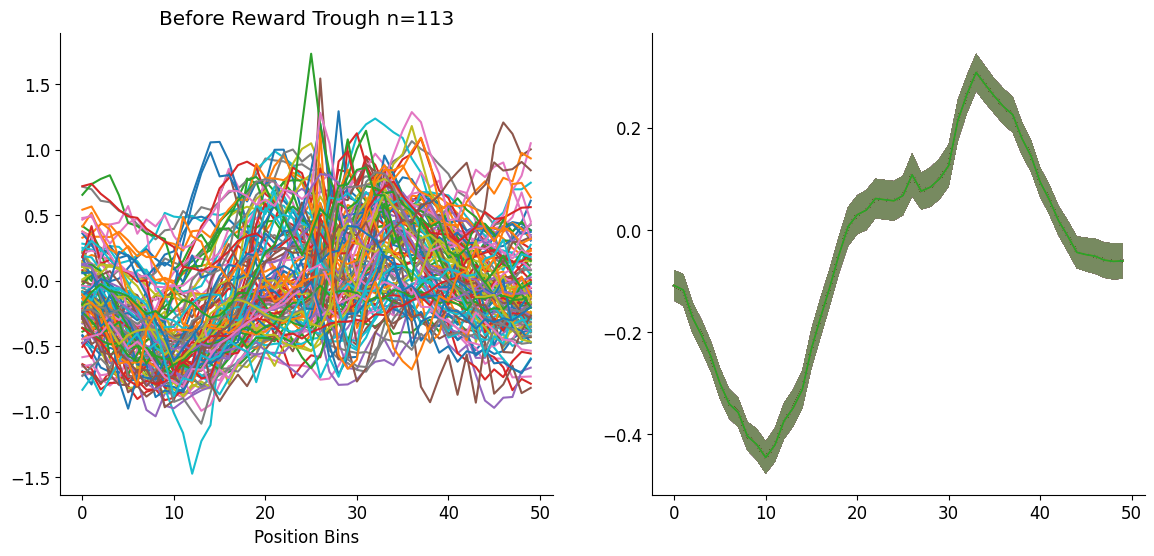

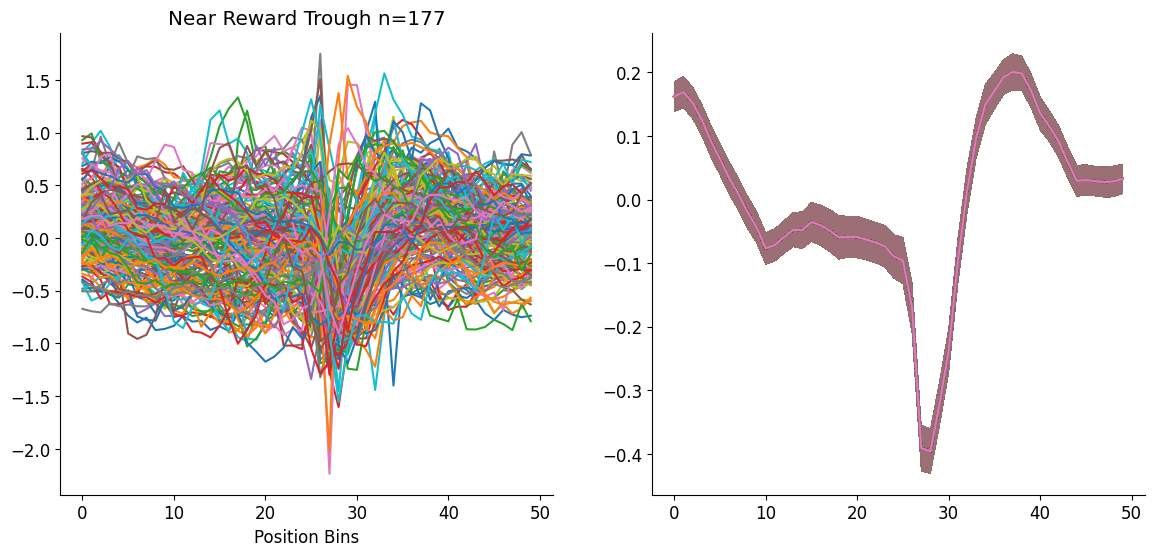

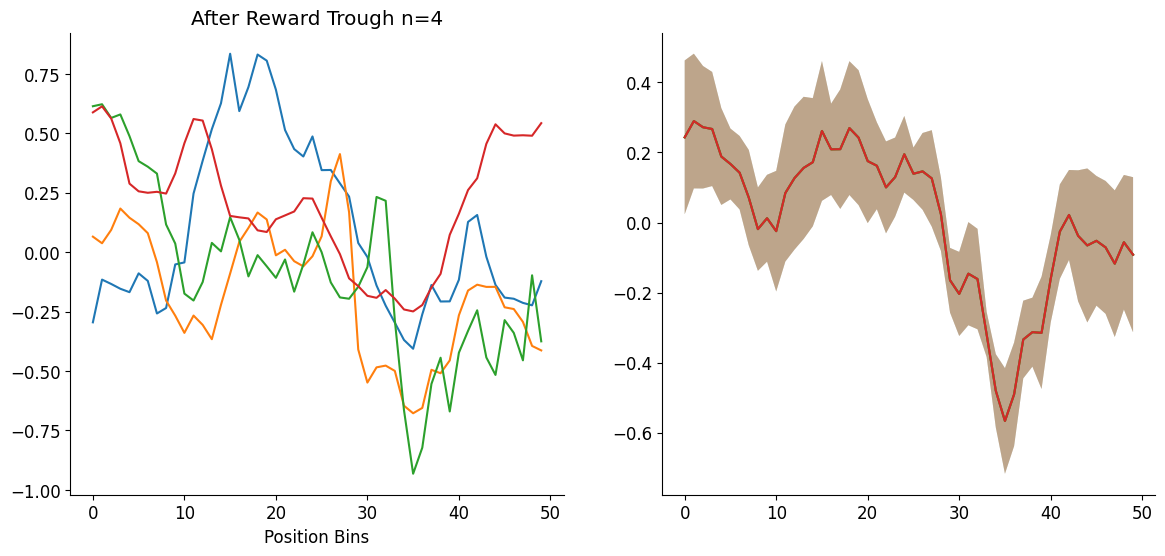

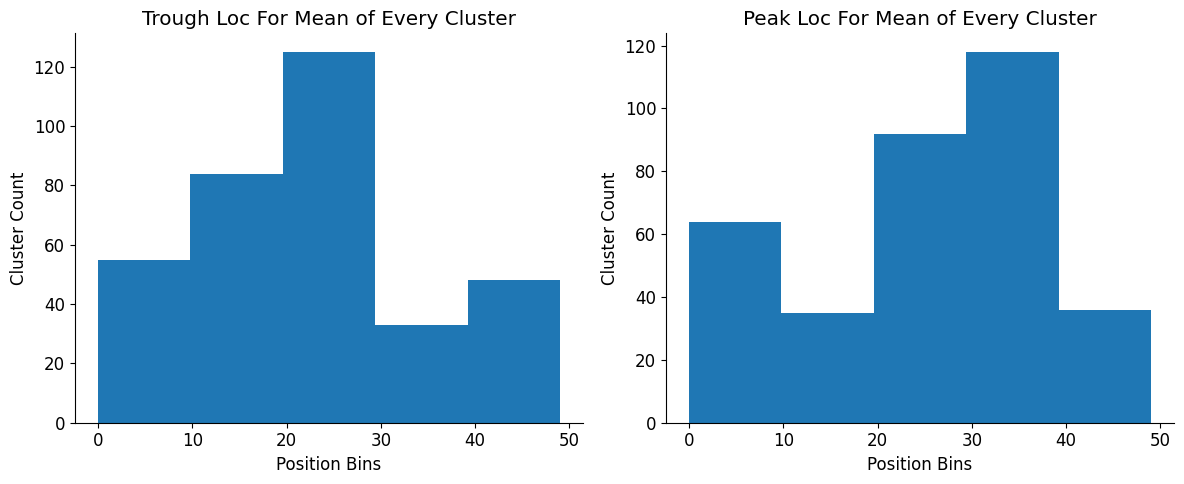

In [ ]:


before_reward = []
near_reward = []
after_reward = []


min_value_list = []
max_value_list = []

for animal in clusters_per_animal_dict:
    data_list = clusters_per_animal_dict[animal]
    data_array = np.array(data_list)
    print(f"data_array.shape")
    for i in range(len(data_list)):
        min_value = np.argmin(data_list[i])
        min_value_list.append(min_value)
        max_value = np.argmax(data_list[i])
        max_value_list.append(max_value)
        if min_value <=15:
            before_reward.append(data_list[i])
        elif 15 < min_value <35:
            near_reward.append(data_list[i])
        elif min_value <=35:
            after_reward.append(data_list[i])




before_reward_array=np.array(before_reward)
mean_before_reward_array = np.mean(before_reward_array, axis=0)
sem_before_reward_array = sem(before_reward_array, axis=0)

near_reward_array=np.array(near_reward)
mean_near_reward_array = np.mean(near_reward_array, axis=0)
sem_near_reward_array = sem(near_reward_array, axis=0)

after_reward_array=np.array(after_reward)
mean_after_reward_array = np.mean(after_reward_array, axis=0)
sem_after_reward_array = sem(after_reward_array, axis=0)

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(before_reward)):
    axs[0].plot(before_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"Before Reward Trough n={len(before_reward)}")

    axs[1].plot(mean_before_reward_array)
    axs[1].fill_between(range(len(mean_before_reward_array)), mean_before_reward_array-sem_before_reward_array, mean_before_reward_array+sem_before_reward_array, alpha=0.2)
    
plt.show()

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(near_reward)):
    axs[0].plot(near_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"Near Reward Trough n={len(near_reward)}")

    axs[1].plot(mean_near_reward_array)
    axs[1].fill_between(range(len(mean_near_reward_array)), mean_near_reward_array-sem_near_reward_array, mean_near_reward_array+sem_near_reward_array, alpha=0.2)

plt.show()

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(after_reward)):
    axs[0].plot(after_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"After Reward Trough n={len(after_reward)}")

    axs[1].plot(mean_after_reward_array)
    axs[1].fill_between(range(len(mean_after_reward_array)), mean_after_reward_array-sem_after_reward_array, mean_after_reward_array+sem_after_reward_array, alpha=0.2)

plt.show()


min_value_array = np.array(min_value_list)
max_value_array = np.array(max_value_list)

fig, axs = plt.subplots(1,2, figsize=(12,5))
axs[0].hist(min_value_array, bins=5)
axs[0].set_title("Trough Loc For Mean of Every Cluster")
axs[0].set_xlabel("Position Bins")
axs[0].set_ylabel("Cluster Count")

axs[1].hist(max_value_array, bins=5)
axs[1].set_title("Peak Loc For Mean of Every Cluster")
axs[1].set_xlabel("Position Bins")
axs[1].set_ylabel("Cluster Count")

plt.tight_layout()
plt.show()

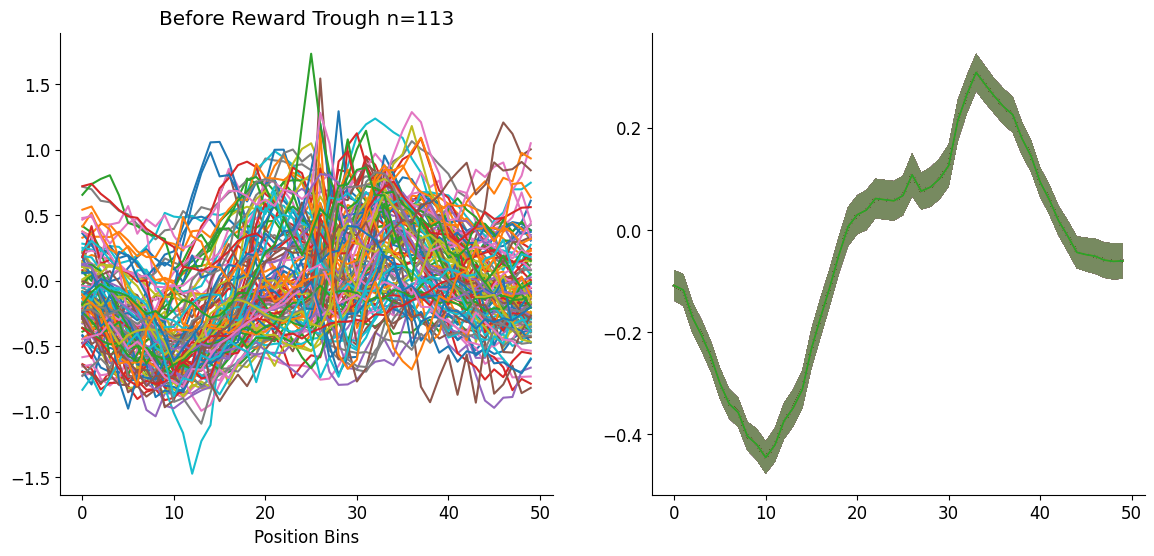

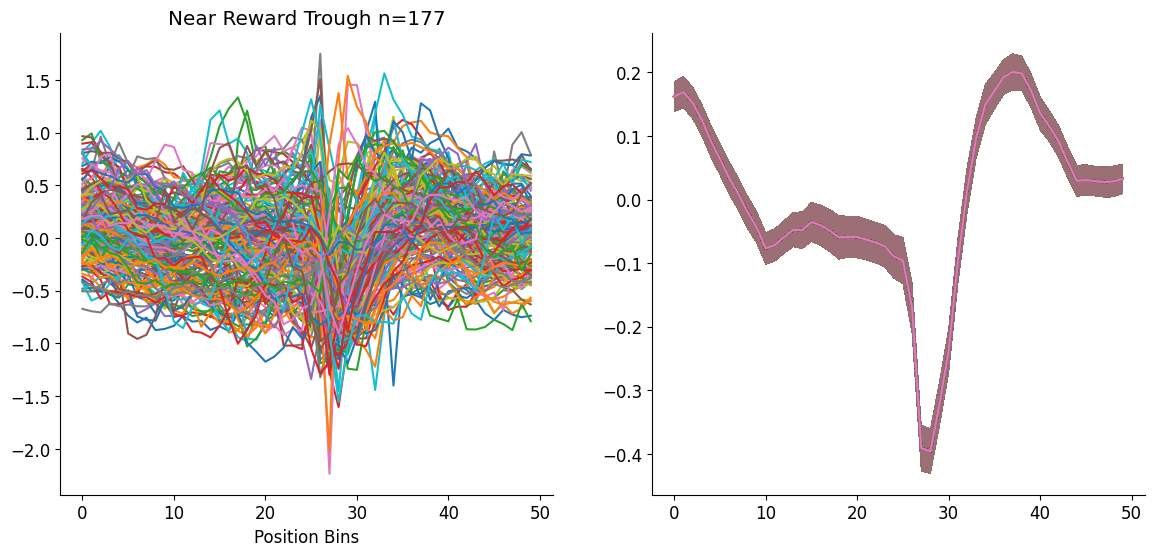

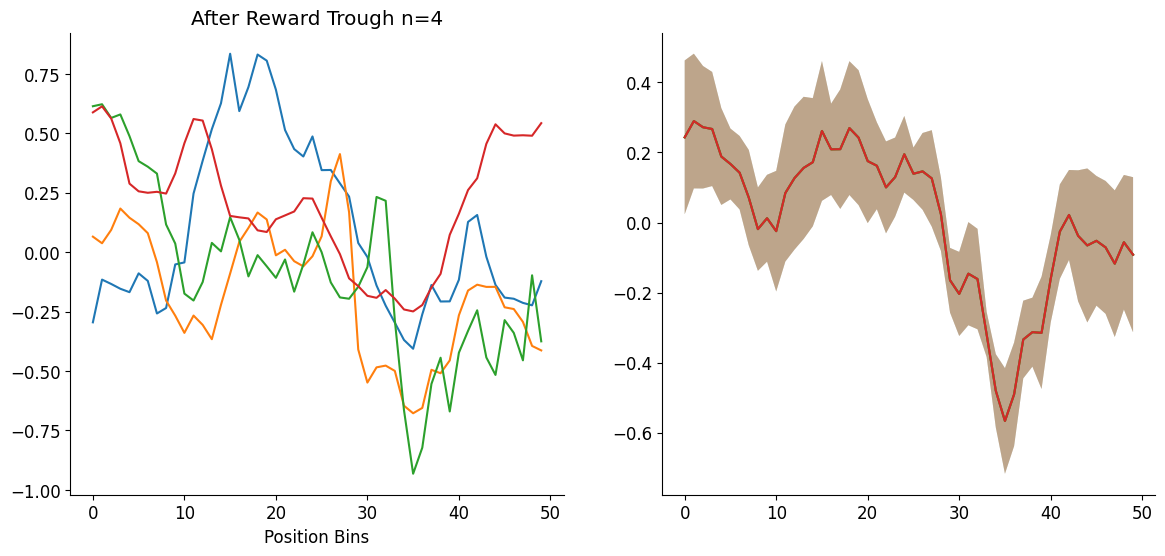

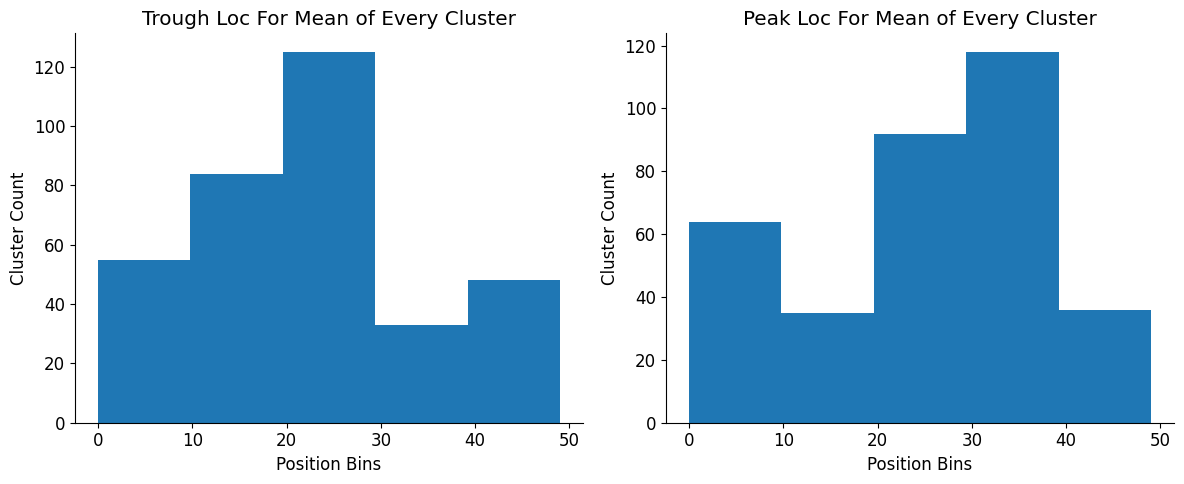

In [ ]:


before_reward = []
near_reward = []
after_reward = []


min_value_list = []
max_value_list = []

for animal in clusters_per_animal_dict:
    data_list = clusters_per_animal_dict[animal]
    for i in range(len(data_list)):
        min_value = np.argmin(data_list[i])
        min_value_list.append(min_value)
        max_value = np.argmax(data_list[i])
        max_value_list.append(max_value)
        if min_value <=15:
            before_reward.append(data_list[i])
        elif 15 < min_value <35:
            near_reward.append(data_list[i])
        elif min_value <=35:
            after_reward.append(data_list[i])




before_reward_array=np.array(before_reward)
mean_before_reward_array = np.mean(before_reward_array, axis=0)
sem_before_reward_array = sem(before_reward_array, axis=0)

near_reward_array=np.array(near_reward)
mean_near_reward_array = np.mean(near_reward_array, axis=0)
sem_near_reward_array = sem(near_reward_array, axis=0)

after_reward_array=np.array(after_reward)
mean_after_reward_array = np.mean(after_reward_array, axis=0)
sem_after_reward_array = sem(after_reward_array, axis=0)

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(before_reward)):
    axs[0].plot(before_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"Before Reward Trough n={len(before_reward)}")

    axs[1].plot(mean_before_reward_array)
    axs[1].fill_between(range(len(mean_before_reward_array)), mean_before_reward_array-sem_before_reward_array, mean_before_reward_array+sem_before_reward_array, alpha=0.2)
    
plt.show()

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(near_reward)):
    axs[0].plot(near_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"Near Reward Trough n={len(near_reward)}")

    axs[1].plot(mean_near_reward_array)
    axs[1].fill_between(range(len(mean_near_reward_array)), mean_near_reward_array-sem_near_reward_array, mean_near_reward_array+sem_near_reward_array, alpha=0.2)

plt.show()

fig, axs = plt.subplots(1,2, figsize=(14,6))
for i in range(len(after_reward)):
    axs[0].plot(after_reward[i])
    axs[0].set_xlabel("Position Bins")
    axs[0].set_title(f"After Reward Trough n={len(after_reward)}")

    axs[1].plot(mean_after_reward_array)
    axs[1].fill_between(range(len(mean_after_reward_array)), mean_after_reward_array-sem_after_reward_array, mean_after_reward_array+sem_after_reward_array, alpha=0.2)

plt.show()


min_value_array = np.array(min_value_list)
max_value_array = np.array(max_value_list)

fig, axs = plt.subplots(1,2, figsize=(12,5))
axs[0].hist(min_value_array, bins=5)
axs[0].set_title("Trough Loc For Mean of Every Cluster")
axs[0].set_xlabel("Position Bins")
axs[0].set_ylabel("Cluster Count")

axs[1].hist(max_value_array, bins=5)
axs[1].set_title("Peak Loc For Mean of Every Cluster")
axs[1].set_xlabel("Position Bins")
axs[1].set_ylabel("Cluster Count")

plt.tight_layout()
plt.show()

In [140]:
# def get_animals_models_animal(fixed_activity_dict_NDNF_newest, animal):
# models_list = []


models_dict = {}

for animal in fixed_activity_dict_NDNF_newest:
    cell_list = []

    for cell in fixed_activity_dict_NDNF_newest[animal]:
        cell_list.append(fixed_activity_dict_NDNF_newest[animal][cell])

    cell_array = np.array(cell_list)
    cell_array = torch.from_numpy(cell_array)


    example_NDNF_cell_tensor = cell_array.permute(2,0,1)

    print(example_NDNF_cell_tensor.shape)


#     example_NDNF_cell = fixed_activity_dict_NDNF_newest[animal][cell]

#     example_NDNF_cell_tensor = torch.from_numpy(example_NDNF_cell).unsqueeze(axis=1)
#     example_NDNF_cell_tensor = example_NDNF_cell_tensor.permute(2, 1, 0)
#     print(example_NDNF_cell_tensor.shape)  # should now be torch.Size([78, 1, 50])

    components_10, model_10_NDNF = slicetca.decompose(example_NDNF_cell_tensor,
                                        number_components=(0,0,10), # (trials, neurons, time bins)
                                        positive=False,
                                        learning_rate=1*10**-3,
                                        min_std=10**-5,
                                        max_iter=15_000,
                                        seed=0)
    

    models_dict[animal] = model_10_NDNF
    

    
#     models_list.append(model_10_NDNF)
#     return models_list


# models_dict_per_animal = {}
# for animal in fixed_activity_dict_NDNF_newest:
#     models_list_animal = get_animals_models(fixed_activity_dict_NDNF_newest, animal)
#     models_dict_per_animal[animal] = models_list_animal

torch.Size([107, 7, 50])


The model converged. Loss: 0.15657848306149105 :  30%|██▉       | 4434/15000 [00:30<01:13, 143.19it/s]


torch.Size([390, 10, 50])


The model converged. Loss: 0.12487635846475321 :  24%|██▍       | 3622/15000 [00:41<02:11, 86.83it/s] 


torch.Size([172, 9, 50])


...

The model converged. Loss: 0.17382726877042085 :  33%|███▎      | 4952/15000 [00:38<01:18, 128.50it/s]


torch.Size([195, 8, 50])


The model converged. Loss: 0.11305509965048903 :  28%|██▊       | 4234/15000 [00:36<01:32, 116.24it/s]


torch.Size([100, 6, 50])


The model converged. Loss: 0.16969442588982886 :  29%|██▉       | 4410/15000 [00:26<01:04, 164.31it/s]


In [ ]:
def get_cluster_labels(models_dict, use_pca=False, pca_dims=None, n_clusters=None):
    labels_cells_dict = {}
    for idx, model_name in enumerate(models_dict):
        model = models_dict[model_name]
        w1 = model.vectors[2][0]
        f1 = model.vectors[2][1]

        print(f"w1.shape {w1.shape} f1.shape {f1.shape}")

        F = f1.detach().cpu().numpy()
        X = np.moveaxis(F, 2, 0)              # X: (cells=7, latents=10, feats=107)
        X = X.reshape(X.shape[0], -1)         # X: (7, 10*107)

        # z-score features across cells (critical given tiny N)
        # Xz = StandardScaler(with_mean=True, with_std=True).fit_transform(X)

        if use_pca:
            Xp = PCA(n_components=6, random_state=0).fit_transform(X)


            labels_cells = KMeans(n_clusters=n_clusters, n_init=100, random_state=0).fit_predict(Xp)
            labels_cells_dict[model_name] = labels_cells

        else:
            labels_cells = KMeans(n_clusters=n_clusters, n_init=100, random_state=0).fit_predict(X)
            labels_cells_dict[model_name] = labels_cells
            print("cell labels:", labels_cells)

    return labels_cells_dict








w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 107, 7])
cell labels: [0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 390, 10])
cell labels: [0 0 0 0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 172, 9])
cell labels: [0 0 0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 162, 8])
cell labels: [0 0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 116, 8])
cell labels: [0 0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 180, 9])
cell labels: [0 0 0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 122, 12])
cell labels: [0 0 0 0 0 0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 128, 13])
cell labels: [0 0 0 0 0 0 0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 251, 8])
cell labels: [0 0 0 0 0 0 0 0]
w1.shape torch.Size([10, 50]) f1.shape torch.Size([10, 227, 9])
cell labels: [0 0 0 0 0 0 0 0 0]
w1.shape torch.Size([

In [193]:
real_data_dict = {}
for animal in fixed_activity_dict_NDNF_newest:
    cell_list = []

    for cell in fixed_activity_dict_NDNF_newest[animal]:
        cell_list.append(fixed_activity_dict_NDNF_newest[animal][cell])

    cell_array = np.array(cell_list)
    real_data_dict[animal] = cell_array

In [222]:

real_data_mean_array_animal_dict_clusters = {}
means_dict_cluster= {}
for num_clusters in labels_cells_dict_all_K:
    real_data_mean_array_animal_dict = {}
    means_dict = {}
    for animal in labels_cells_dict_all_K[num_clusters]:
        real_data = real_data_dict[animal]
        # print(real_data.shape)
        labels = labels_cells_dict_all_K[num_clusters][animal]
        print(f"animal {animal} labels {labels}")
        uniq = np.unique(labels)
        real_data_mean_array = np.empty(real_data.shape)
        mean_data_dict = {}
        mean_data_list = []
        fraction_cells_list = []
        for i in uniq:
            labels_loc = np.where(labels==i)[0]
            fraction_cells = (len(labels_loc) / real_data.shape[0])*100
            fraction_cells_list.append(fraction_cells)
            real_data_array_sliced = real_data[labels_loc,:,:]
            print(f"real_data_array_sliced.shape {real_data_array_sliced.shape}")
            mean_real_data_array_sliced = np.mean(real_data_array_sliced, axis=0)
            mean_data_list.append(mean_real_data_array_sliced)
            real_data_mean_array[labels_loc,:,:] = mean_real_data_array_sliced
        mean_data_dict = {"mean_data_list":mean_data_list,
                       "fraction_cells":fraction_cells_list}
        real_data_mean_array_animal_dict[animal] = real_data_mean_array
        means_dict[animal] = mean_data_dict
    real_data_mean_array_animal_dict_clusters[num_clusters] = real_data_mean_array_animal_dict
    means_dict_cluster[num_clusters] = means_dict

# real_data_mean_array_animal_dict_clusters = {}

# for K, animal_labels in labels_cells_dict_all_K.items():
#     per_animal = {}
#     for animal, labels in animal_labels.items():
#         real_data = real_data_dict[animal]          # shape: (Ncells, 50, 107)
#         labels = np.asarray(labels)
#         assert labels.shape[0] == real_data.shape[0], "labels vs real_data mismatch"

#         uniq = np.unique(labels)
#         # Map actual labels -> [0..K'-1] positions
#         lut = {lab: i for i, lab in enumerate(uniq)}
#         idx = np.array([lut[l] for l in labels], dtype=int)  # shape (Ncells,)

#         # Compute per-cluster means
#         means = []
#         for lab in uniq:
#             pick = (labels == lab)
#             if not np.any(pick):                # empty cluster guard
#                 means.append(np.zeros((50, 107), dtype=real_data.dtype))
#             else:
#                 means.append(real_data[pick].mean(axis=0))
#         means = np.stack(means, axis=0)         # (K', 50, 107)

#         # Broadcast back to each cell: mean of its cluster
#         real_data_mean_array = means[idx]       # (Ncells, 50, 107)

#         per_animal[animal] = real_data_mean_array
#     real_data_mean_array_animal_dict_clusters[K] = per_animal




animal animal_19 labels [0 0 0 0 0 0 0]
real_data_array_sliced.shape (7, 50, 107)
animal animal_20 labels [0 0 0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (10, 50, 390)
animal animal_21 labels [0 0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (9, 50, 172)
animal animal_22 labels [0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (8, 50, 162)
animal animal_23 labels [0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (8, 50, 116)
animal animal_24 labels [0 0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (9, 50, 180)
animal animal_25 labels [0 0 0 0 0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (12, 50, 122)
animal animal_26 labels [0 0 0 0 0 0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (13, 50, 128)
animal animal_27 labels [0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (8, 50, 251)
animal animal_28 labels [0 0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (9, 50, 227)
animal animal_29 labels [0 0 0 0 0 0 0 0]
real_data_array_sliced.shape (8, 50, 146)
animal animal_30 labels [0 0 0 0 0 0 0 0]
real_

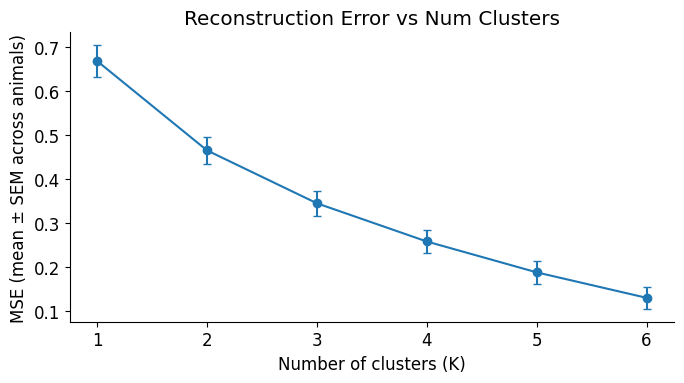

In [196]:
MSE_dict_per_animal = {} 

for num_clusters in real_data_mean_array_animal_dict_clusters:
    MSE_list_per_animal = []
    for animal in real_data_mean_array_animal_dict_clusters[num_clusters]:
        real_data_tensor = real_data_dict[animal]
        reco_data_tensor = real_data_mean_array_animal_dict_clusters[num_clusters][animal]
        MSE = np.mean(np.square(real_data_tensor-reco_data_tensor))
        MSE_list_per_animal.append(MSE)
    MSE_dict_per_animal[num_clusters] = MSE_list_per_animal


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

Ks = sorted(MSE_dict_per_animal.keys())
vals = [np.asarray(MSE_dict_per_animal[K], dtype=float) for K in Ks]

means = np.array([v.mean() if v.size else np.nan for v in vals])
sems  = np.array([sem(v, ddof=1) if v.size > 1 else np.nan for v in vals])

plt.figure(figsize=(7,4))
plt.errorbar(Ks, means, yerr=sems, fmt='-o', capsize=3)
plt.xlabel("Number of clusters (K)")
plt.ylabel("MSE (mean ± SEM across animals)")
plt.title("Reconstruction Error vs Num Clusters")
plt.tight_layout()
plt.show()

   


6

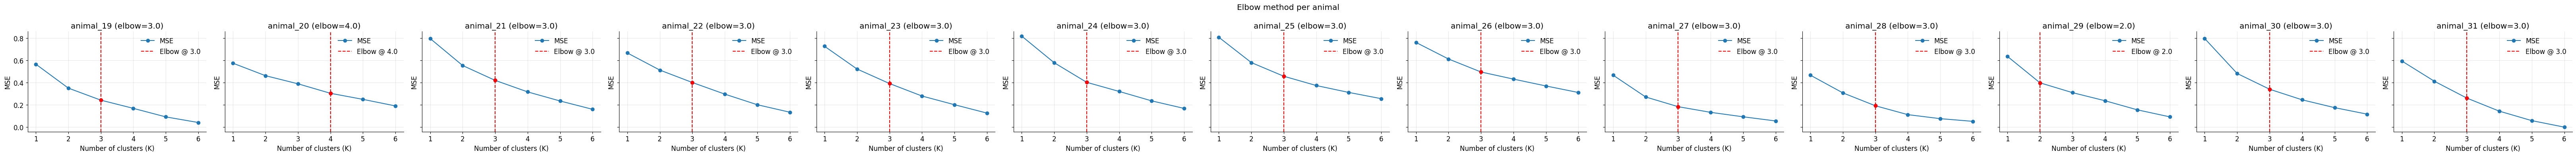

Detected elbows per animal: {'animal_19': 3.0, 'animal_20': 4.0, 'animal_21': 3.0, 'animal_22': 3.0, 'animal_23': 3.0, 'animal_24': 3.0, 'animal_25': 3.0, 'animal_26': 3.0, 'animal_27': 3.0, 'animal_28': 3.0, 'animal_29': 2.0, 'animal_30': 3.0, 'animal_31': 3.0}


In [209]:
import numpy as np
import matplotlib.pyplot as plt
import kneed
from kneed import KneeLocator

animals = list(real_data_dict.keys())
Ks = sorted(MSE_dict_per_animal.keys())

# Build: per_animal_dict[animal] = list of MSEs across K
per_animal_dict = {animal: [] for animal in animals}
for K in Ks:
    mse_list = MSE_dict_per_animal[K]
    for idx, animal in enumerate(animals):
        if idx < len(mse_list):
            per_animal_dict[animal].append(mse_list[idx])
        else:
            per_animal_dict[animal].append(np.nan)

elbow_points = {}

fig, axs = plt.subplots(1, len(animals), figsize=(5*len(animals), 4), sharey=True)

if len(animals) == 1:
    axs = [axs]

for ax, animal in zip(axs, animals):
    y = np.array(per_animal_dict[animal], dtype=float)
    x = np.array(Ks, dtype=float)

    # Fit KneeLocator
    kneedle = KneeLocator(x, y, curve="convex", direction="decreasing", S=0.4)
    elbow = kneedle.knee
    elbow_points[animal] = elbow

    # Plot
    ax.plot(x, y, marker="o", label="MSE")
    if elbow is not None:
        ax.axvline(elbow, color="red", linestyle="--", label=f"Elbow @ {elbow}")
        ax.scatter(elbow, y[x.tolist().index(elbow)], color="red", zorder=5)
    ax.set_title(f"{animal} (elbow={elbow})")
    ax.set_xlabel("Number of clusters (K)")
    ax.set_ylabel("MSE")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Elbow method per animal")
plt.tight_layout()
plt.show()

print("Detected elbows per animal:", elbow_points)


Text(0.5, 1.0, 'Trough Loc > Pos Bin 35')

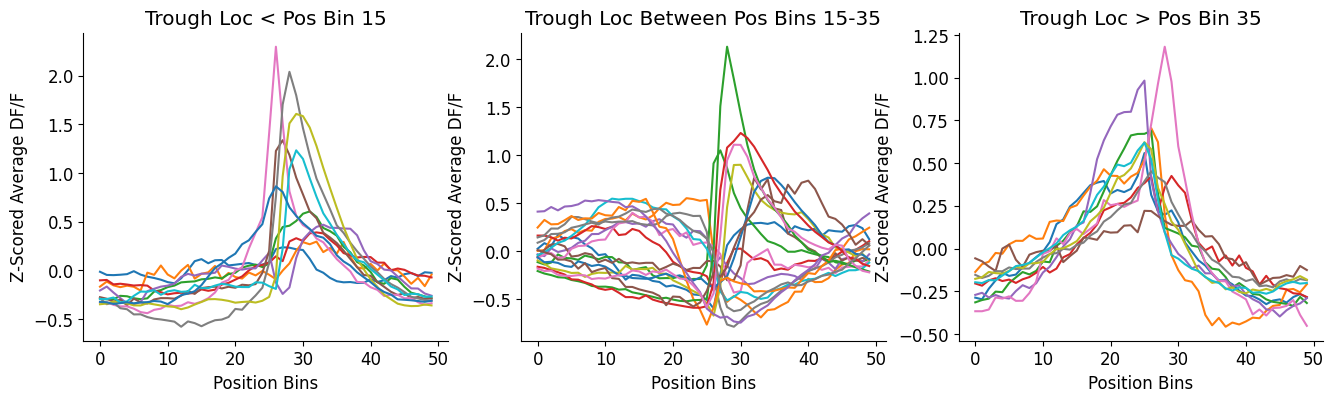

In [238]:
trough_loc_list = []
peak_loc_list = []

before_reward = []
near_reward = []
after_reward = []

for animal in mean_cluster_dict_per_animal:
    for cluster_id in mean_cluster_dict_per_animal[animal]:
        data = mean_cluster_dict_per_animal[animal][cluster_id]
        troughloc = np.argmin(data)
        trough_loc_list.append(troughloc)
        peakloc = np.argmax(data)
        peak_loc_list.append(peakloc)
        if troughloc <=15:
            before_reward.append(data)
        elif 15 < troughloc <35:
            near_reward.append(data)
        elif troughloc >=35:
            after_reward.append(data)



fig, axs = plt.subplots(1,3, figsize=(16,4))

for i in range(len(before_reward)):
    axs[0].plot(before_reward[i])
axs[0].set_ylabel("Z-Scored Average DF/F")
axs[0].set_xlabel("Position Bins")
axs[0].set_title("Trough Loc < Pos Bin 15")

for i in range(len(near_reward)):
    axs[1].plot(near_reward[i])
axs[1].set_ylabel("Z-Scored Average DF/F")
axs[1].set_xlabel("Position Bins")
axs[1].set_title("Trough Loc Between Pos Bins 15-35")

for i in range(len(after_reward)):
    axs[2].plot(after_reward[i])
axs[2].set_ylabel("Z-Scored Average DF/F")
axs[2].set_xlabel("Position Bins")
axs[2].set_title("Trough Loc > Pos Bin 35")

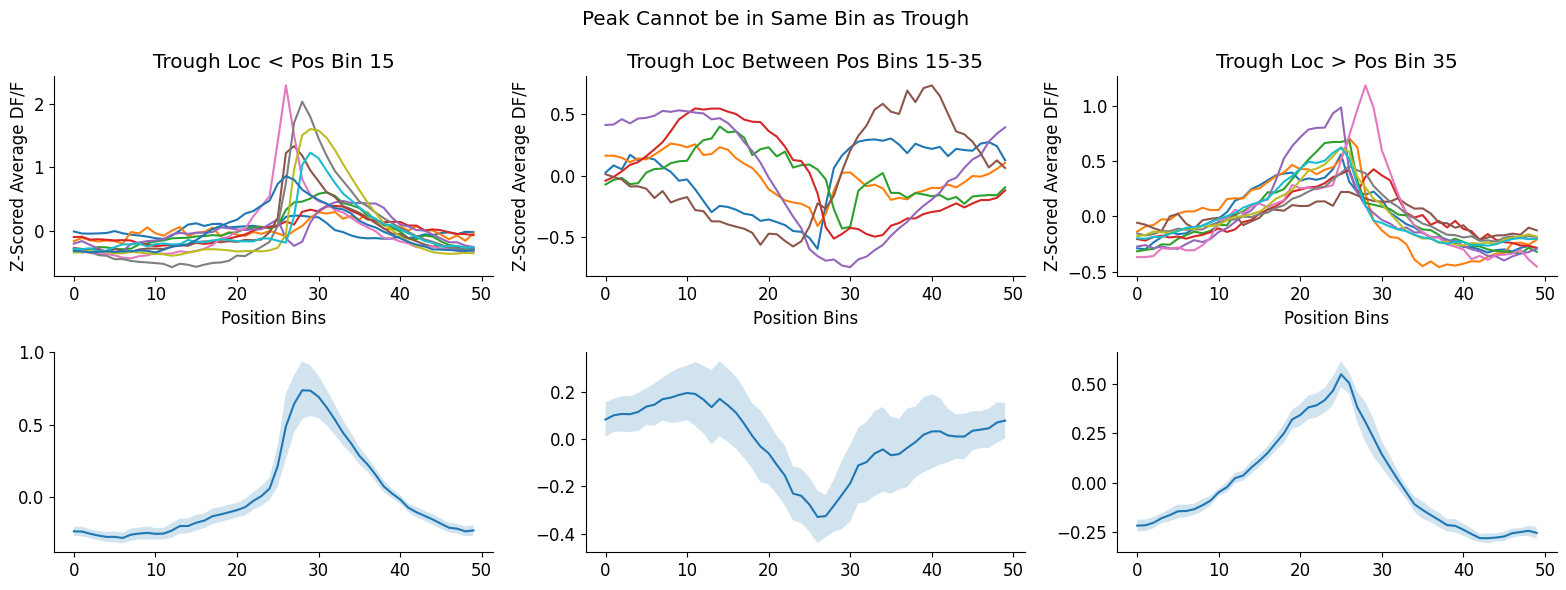

In [244]:
########################## cannot have its trough and peak in the same bin 

trough_loc_list = []
peak_loc_list = []

before_reward = []
near_reward = []
after_reward = []

for animal in mean_cluster_dict_per_animal:
    for cluster_id in mean_cluster_dict_per_animal[animal]:
        data = mean_cluster_dict_per_animal[animal][cluster_id]
        troughloc = np.argmin(data)
        trough_loc_list.append(troughloc)
        peakloc = np.argmax(data)
        peak_loc_list.append(peakloc)
        if troughloc <=15 and peakloc >=15:
            before_reward.append(data)
        elif 15 < troughloc <35 and (peakloc >=35 or peakloc <=15):
            near_reward.append(data)
        elif troughloc >=35 and peakloc <=35:
            after_reward.append(data)



fig, axs = plt.subplots(2,3, figsize=(16,6))
plt.suptitle("Peak Cannot be in Same Bin as Trough")

for i in range(len(before_reward)):
    axs[0,0].plot(before_reward[i])
axs[0,0].set_ylabel("Z-Scored Average DF/F")
axs[0,0].set_xlabel("Position Bins")
axs[0,0].set_title("Trough Loc < Pos Bin 15")

before_reward_array = np.array(before_reward)
mean_before_reward_array = np.mean(before_reward_array, axis=0)
sem_before_reward_array = sem(before_reward_array, axis=0)

axs[1,0].plot(mean_before_reward_array)
axs[1,0].fill_between(range(len(mean_before_reward_array)), mean_before_reward_array+sem_before_reward_array, mean_before_reward_array-sem_before_reward_array, alpha=0.2)

for i in range(len(near_reward)):
    axs[0,1].plot(near_reward[i])
axs[0,1].set_ylabel("Z-Scored Average DF/F")
axs[0,1].set_xlabel("Position Bins")
axs[0,1].set_title("Trough Loc Between Pos Bins 15-35")

near_reward_array=(np.array(near_reward))
mean_near_reward_array = np.mean(near_reward_array, axis=0)
sem_near_reward_array = sem(near_reward_array, axis=0)
axs[1,1].plot(mean_near_reward_array)
axs[1,1].fill_between(range(len(mean_near_reward_array)), mean_near_reward_array+sem_near_reward_array, mean_near_reward_array-sem_near_reward_array, alpha=0.2)

for i in range(len(after_reward)):
    axs[0,2].plot(after_reward[i])
axs[0,2].set_ylabel("Z-Scored Average DF/F")
axs[0,2].set_xlabel("Position Bins")
axs[0,2].set_title("Trough Loc > Pos Bin 35")

after_reward_array=(np.array(after_reward))
mean_after_reward_array = np.mean(after_reward_array, axis=0)
sem_after_reward_array = sem(after_reward_array, axis=0)
axs[1,2].plot(mean_after_reward_array)
axs[1,2].fill_between(range(len(mean_after_reward_array)), mean_after_reward_array+sem_after_reward_array, mean_after_reward_array-sem_after_reward_array, alpha=0.2)

plt.tight_layout()
plt.show()


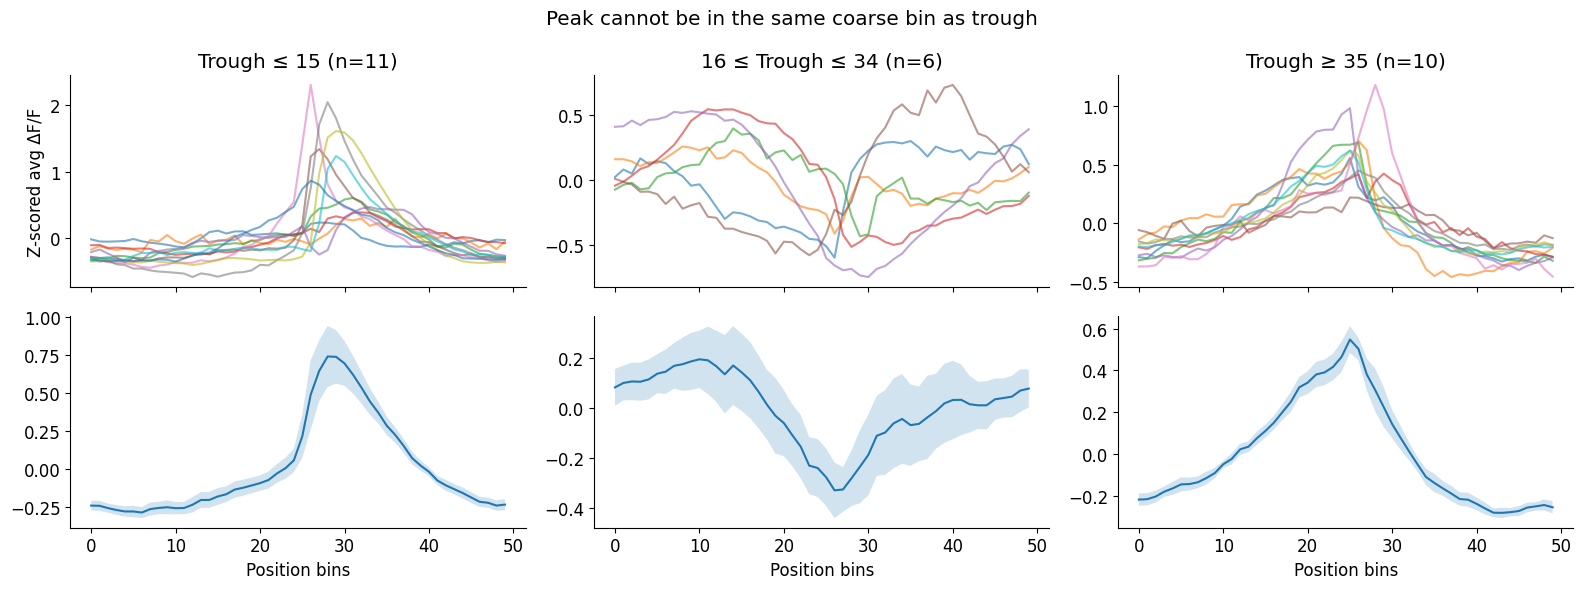

In [245]:
from scipy.stats import sem
import numpy as np
import matplotlib.pyplot as plt

def coarse_bin(idx):
    # define your bins: <=15, 16..34, >=35
    if idx <= 15:
        return "before"
    elif idx < 35:           # 16..34
        return "near"
    else:
        return "after"       # >=35

before_reward, near_reward, after_reward = [], [], []
trough_loc_list, peak_loc_list = [], []

for animal in mean_cluster_dict_per_animal:
    for cluster_id, data in mean_cluster_dict_per_animal[animal].items():
        data = np.asarray(data)
        t = int(np.argmin(data))
        p = int(np.argmax(data))
        trough_loc_list.append(t)
        peak_loc_list.append(p)

        tb, pb = coarse_bin(t), coarse_bin(p)

        # enforce: trough and peak cannot be in the same coarse bin AND not same index
        if tb == pb or t == p:
            continue

        if tb == "before":
            before_reward.append(data)
        elif tb == "near":
            near_reward.append(data)
        else:  # "after"
            after_reward.append(data)

# helper to compute mean/sem safely
def mean_sem(stack):
    if len(stack) == 0:
        return None, None
    A = np.vstack([np.asarray(x)[None, :] for x in stack])
    mean = A.mean(axis=0)
    se = sem(A, axis=0) if A.shape[0] > 1 else np.zeros_like(mean)
    return mean, se

mb, seb = mean_sem(before_reward)
mn, sen = mean_sem(near_reward)
ma, sea = mean_sem(after_reward)

fig, axs = plt.subplots(2, 3, figsize=(16, 6), sharex=True)
plt.suptitle("Peak cannot be in the same coarse bin as trough")

# Before
for x in before_reward:
    axs[0, 0].plot(x, alpha=0.6)
axs[0, 0].set_title(f"Trough ≤ 15 (n={len(before_reward)})")
axs[0, 0].set_ylabel("Z-scored avg ΔF/F")
axs[1, 0].set_xlabel("Position bins")
if mb is not None:
    axs[1, 0].plot(mb)
    axs[1, 0].fill_between(range(len(mb)), mb - seb, mb + seb, alpha=0.2)

# Near
for x in near_reward:
    axs[0, 1].plot(x, alpha=0.6)
axs[0, 1].set_title(f"16 ≤ Trough ≤ 34 (n={len(near_reward)})")
axs[1, 1].set_xlabel("Position bins")
if mn is not None:
    axs[1, 1].plot(mn)
    axs[1, 1].fill_between(range(len(mn)), mn - sen, mn + sen, alpha=0.2)

# After
for x in after_reward:
    axs[0, 2].plot(x, alpha=0.6)
axs[0, 2].set_title(f"Trough ≥ 35 (n={len(after_reward)})")
axs[1, 2].set_xlabel("Position bins")
if ma is not None:
    axs[1, 2].plot(ma)
    axs[1, 2].fill_between(range(len(ma)), ma - sea, ma + sea, alpha=0.2)

plt.tight_layout()
plt.show()


Loss: 0.457597679210631 : 100%|██████████| 4000/4000 [04:14<00:00, 15.69it/s]  


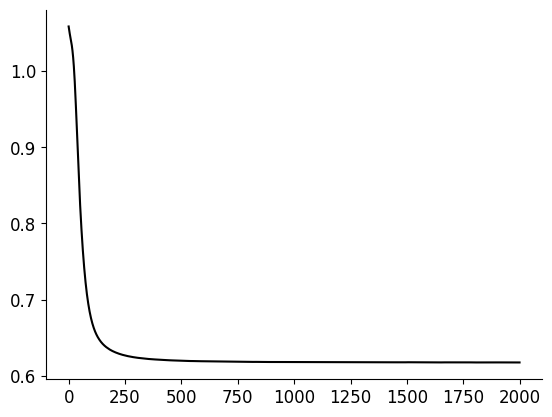

In [ ]:

data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_residual_activity_dict_NDNF_newest)
example_NDNF_cell_tensor = torch.from_numpy(data_truncated_array_NDNF)
example_NDNF_cell_tensor = example_NDNF_cell_tensor.permute(2,0,1)

    
components_10, model_20_NDNF_resid = slicetca.decompose(example_NDNF_cell_tensor,
                                            number_components=(0,20,0), # (trials, neurons, time bins)
                                            positive=False,
                                            learning_rate=1*10**-2,
                                            min_std=10**-5,
                                            max_iter=4000,
                                            iter_std=1000,
                                            seed=0)

plt.plot(model_10_NDNF.losses, color='k')
plt.show()


In [420]:



def get_labels_all_different_Ks_single(model_20_NDNF_resid):


    w1 = model_20_NDNF_resid.vectors[1][0]
    f1 = model_20_NDNF_resid.vectors[1][1]
    F = f1.detach().cpu().numpy()
    W = w1.detach().cpu().numpy()

    X = W.T

    labels_cells_dict_all_K = {}
    for i in range(10):
        K=i+1
        labels_cells = KMeans(n_clusters=K, n_init=100, random_state=42).fit_predict(X)
        labels_cells_dict_all_K[K] = labels_cells


    return labels_cells_dict_all_K

labels_cells_dict_all_K_NDNF_single = get_labels_all_different_Ks_single(model_20_NDNF_resid)





Loss: 0.9368055045544309 : 100%|██████████| 4000/4000 [01:48<00:00, 36.79it/s]


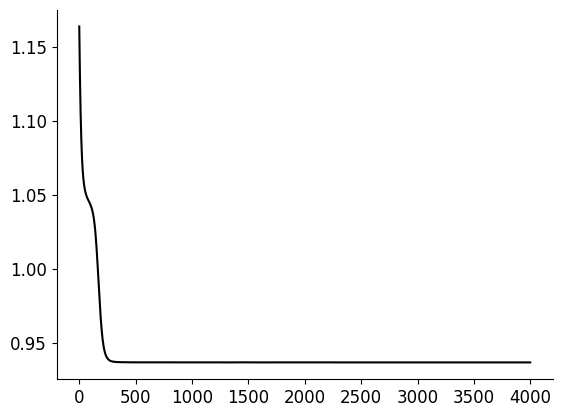

Loss: 0.8575638929193626 : 100%|██████████| 4000/4000 [01:58<00:00, 33.77it/s]


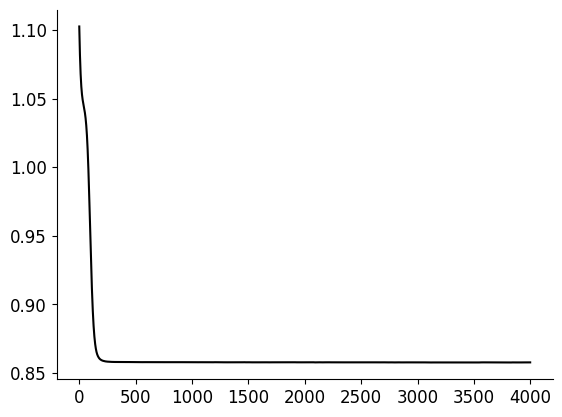

Loss: 0.8102445817334907 : 100%|██████████| 4000/4000 [02:06<00:00, 31.68it/s]


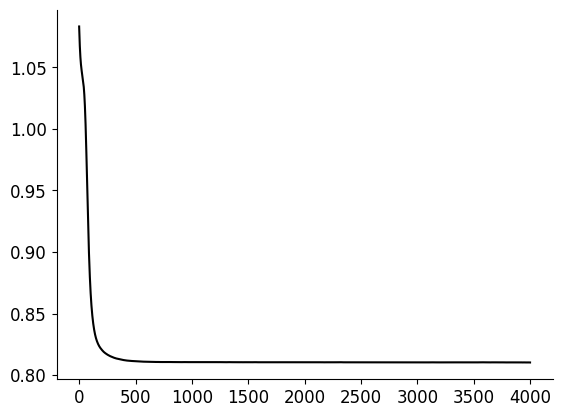

Loss: 0.7736521635952537 : 100%|██████████| 4000/4000 [02:20<00:00, 28.54it/s]


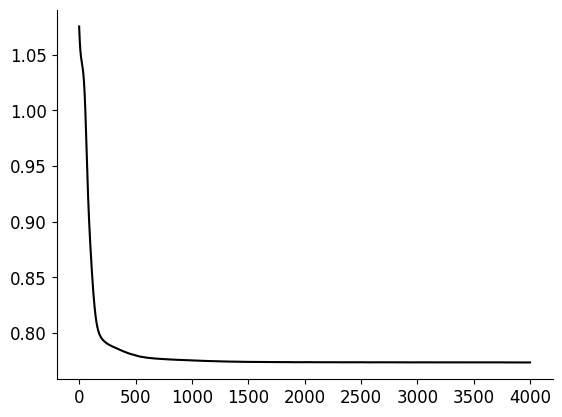

Loss: 0.740716877686972 : 100%|██████████| 4000/4000 [02:20<00:00, 28.38it/s] 


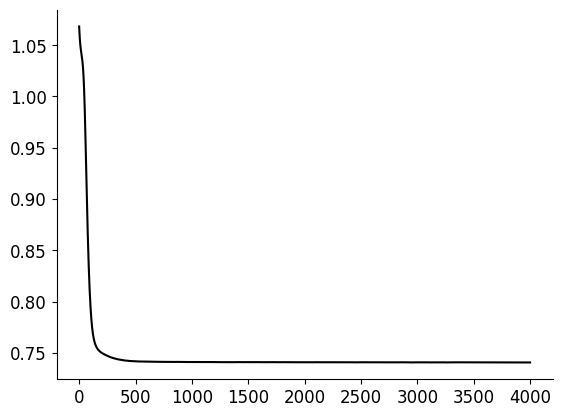

Loss: 0.7118978900503772 : 100%|██████████| 4000/4000 [02:39<00:00, 25.02it/s]


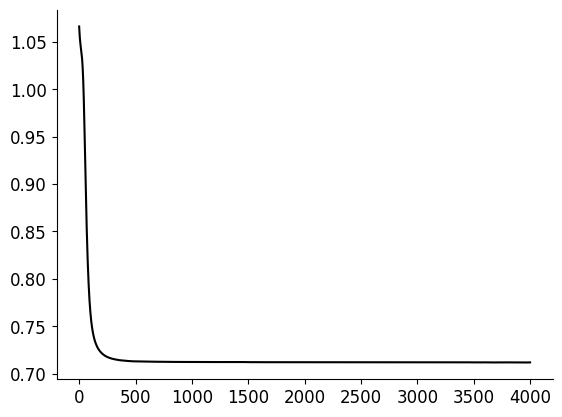

Loss: 0.6863914543590857 : 100%|██████████| 4000/4000 [02:33<00:00, 26.02it/s]


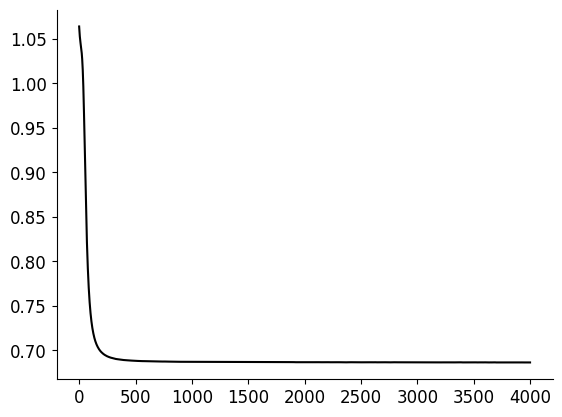

Loss: 0.661826986562401 : 100%|██████████| 4000/4000 [02:54<00:00, 22.86it/s] 


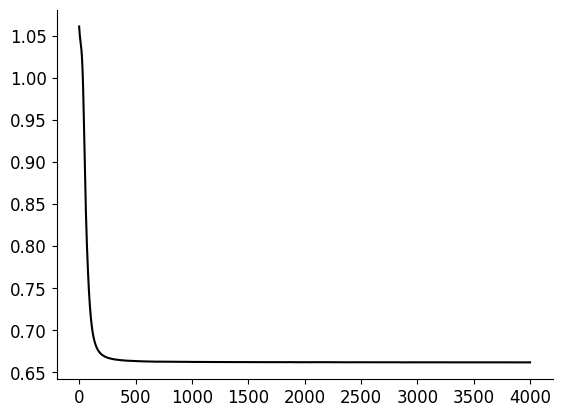

Loss: 0.6383666153361335 : 100%|██████████| 4000/4000 [02:56<00:00, 22.61it/s]


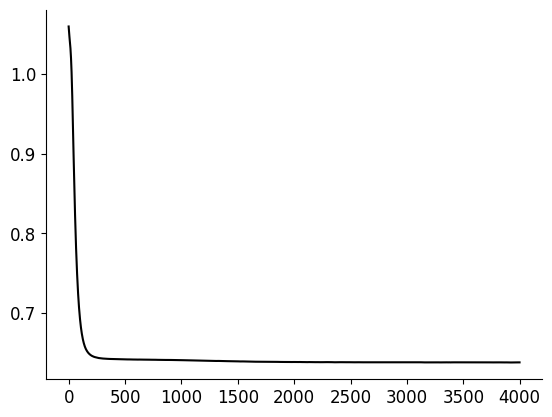

Loss: 0.6173580804782426 : 100%|██████████| 4000/4000 [03:13<00:00, 20.67it/s]


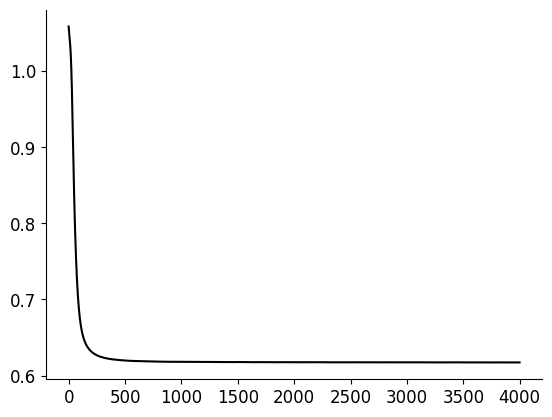

Loss: 0.5965981630415036 : 100%|██████████| 4000/4000 [12:09<00:00,  5.48it/s]  


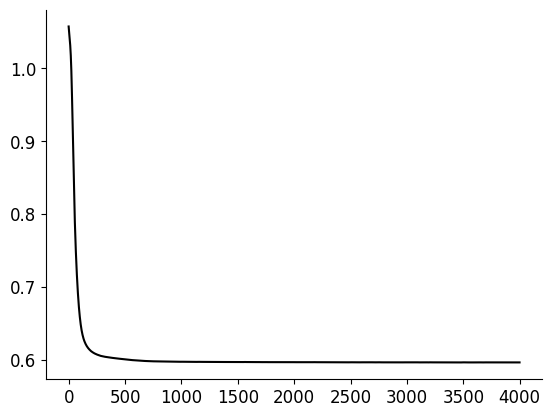

Loss: 0.5768668668605382 : 100%|██████████| 4000/4000 [03:43<00:00, 17.88it/s]


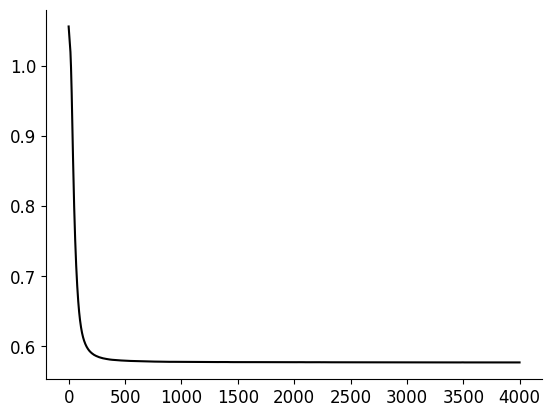

Loss: 0.5590818163820862 : 100%|██████████| 4000/4000 [03:50<00:00, 17.36it/s]


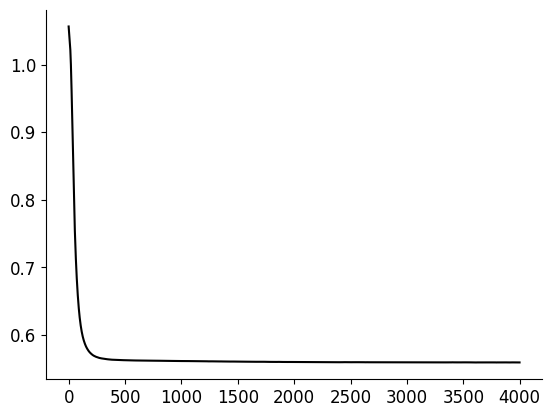

Loss: 0.5427943629480483 : 100%|██████████| 4000/4000 [04:00<00:00, 16.65it/s]


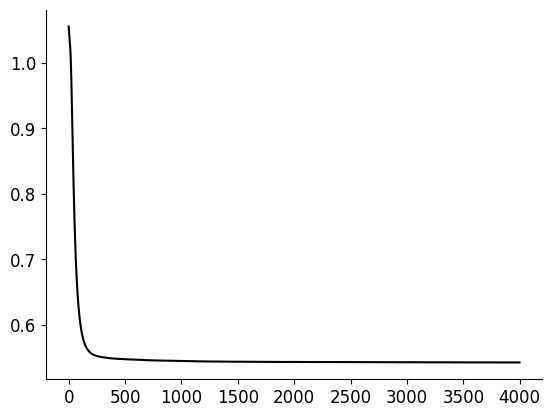

Loss: 0.5264135238341682 : 100%|██████████| 4000/4000 [03:45<00:00, 17.74it/s]


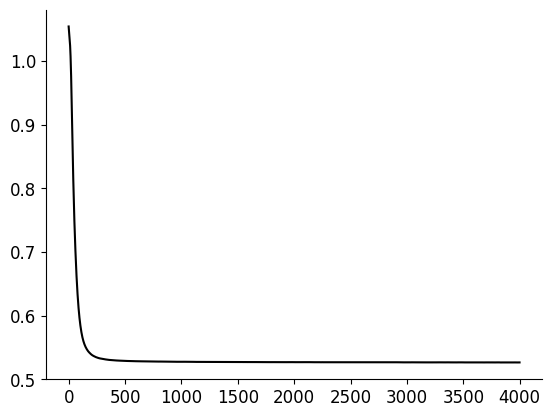

Loss: 0.5107292998513496 : 100%|██████████| 4000/4000 [04:12<00:00, 15.85it/s]


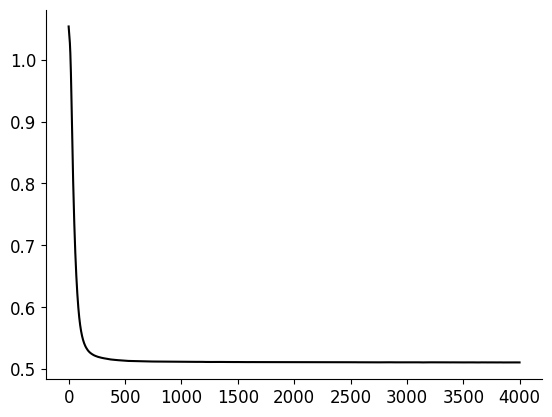

Loss: 0.4958004888442365 : 100%|██████████| 4000/4000 [06:21<00:00, 10.48it/s]  


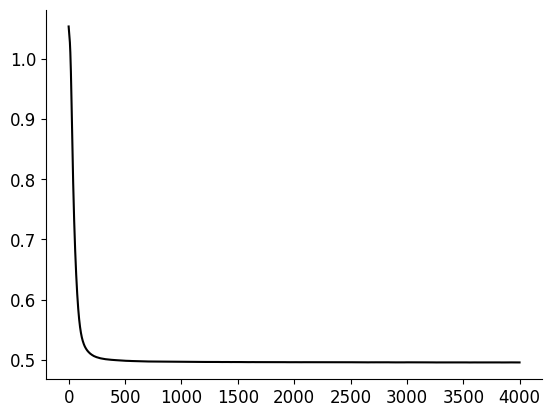

Loss: 0.48161687481995036 : 100%|██████████| 4000/4000 [03:22<00:00, 19.74it/s]


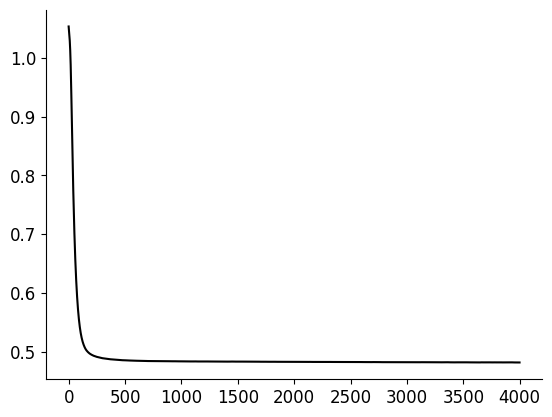

Loss: 0.4682709560299626 : 100%|██████████| 4000/4000 [03:29<00:00, 19.12it/s] 


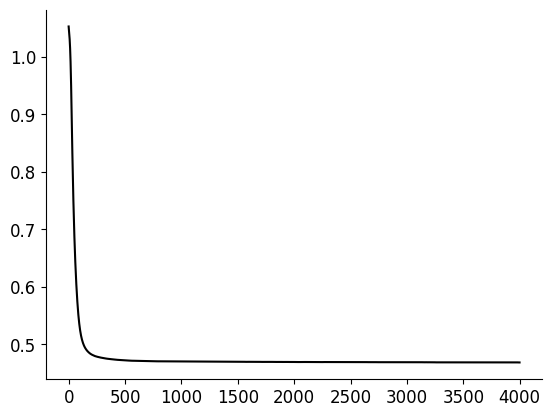

Loss: 0.45524510661071405 : 100%|██████████| 4000/4000 [03:34<00:00, 18.62it/s]


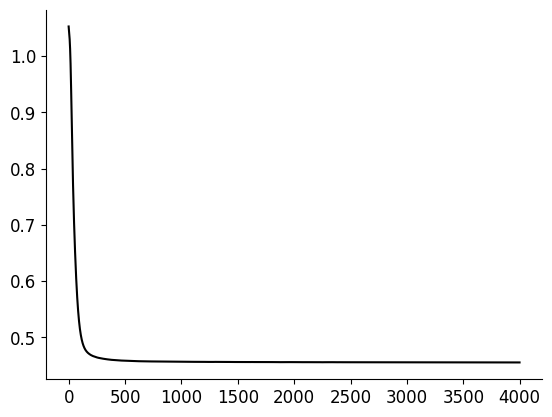

Loss: 0.4428244031079912 : 100%|██████████| 4000/4000 [03:37<00:00, 18.41it/s] 


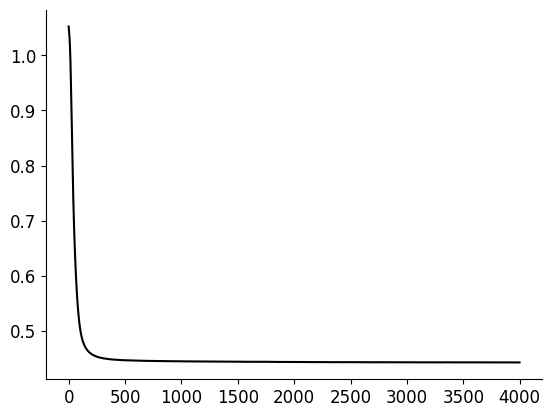

Loss: 0.4308397072917402 : 100%|██████████| 4000/4000 [03:58<00:00, 16.76it/s] 


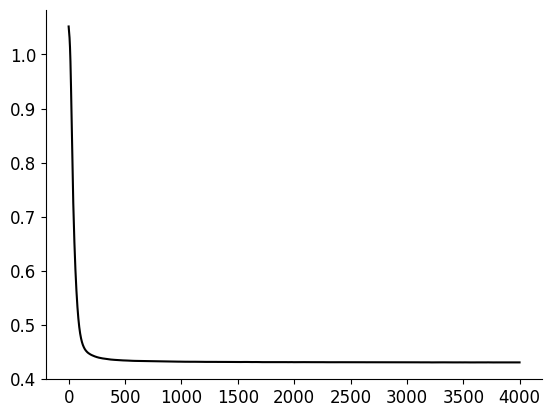

Loss: 0.41960256929410794 : 100%|██████████| 4000/4000 [11:23<00:00,  5.85it/s]   


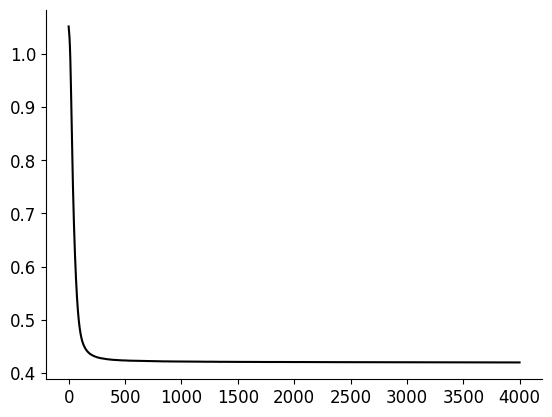

Loss: 0.40840966194899825 : 100%|██████████| 4000/4000 [03:49<00:00, 17.44it/s]


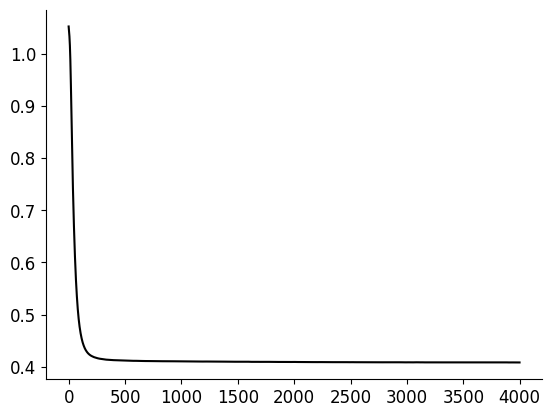

Loss: 0.3980322696903323 : 100%|██████████| 4000/4000 [05:11<00:00, 12.86it/s] 


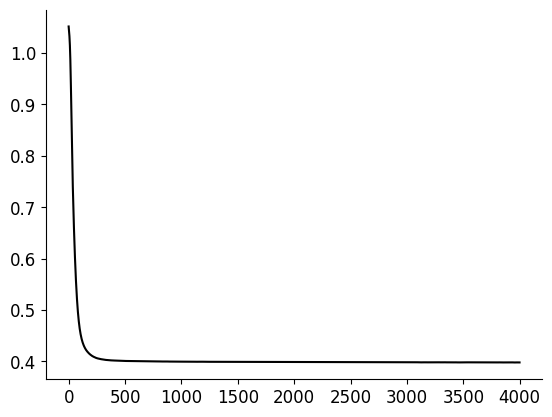

Loss: 0.3880037627976316 : 100%|██████████| 4000/4000 [05:37<00:00, 11.85it/s] 


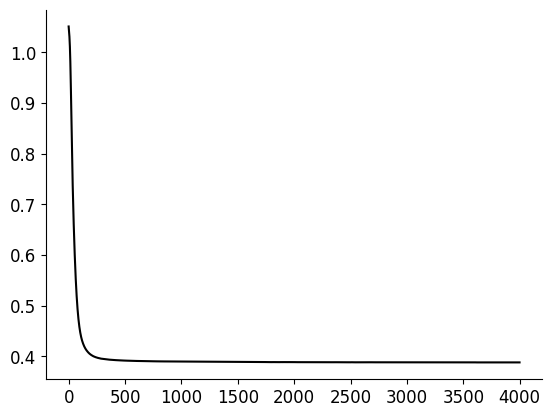

Loss: 0.378317715288777 : 100%|██████████| 4000/4000 [05:49<00:00, 11.43it/s]  


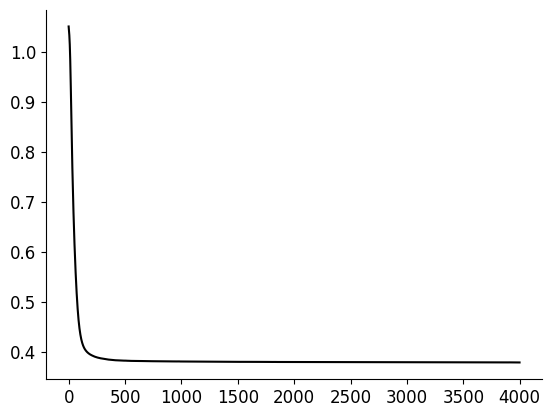

Loss: 0.36938599675697 : 100%|██████████| 4000/4000 [05:32<00:00, 12.02it/s]   


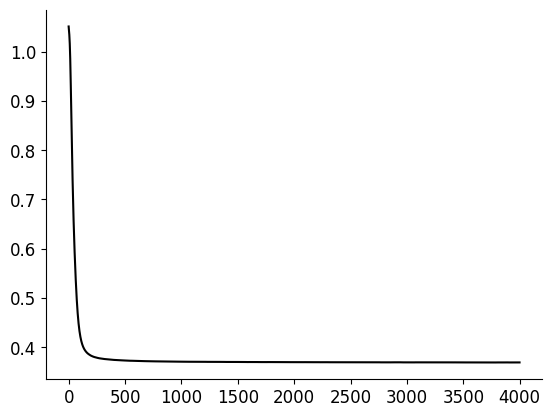

Loss: 0.3602504301829104 : 100%|██████████| 4000/4000 [05:27<00:00, 12.20it/s] 


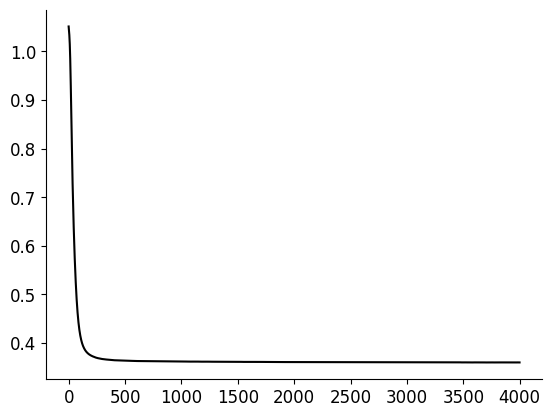

Loss: 0.3513923717039856 : 100%|██████████| 4000/4000 [04:28<00:00, 14.92it/s] 


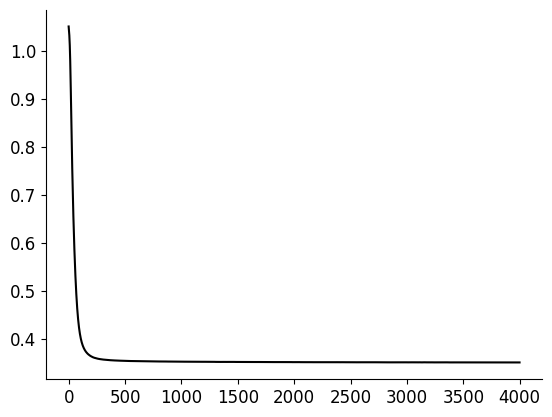

Loss: 0.34295502067004735 : 100%|██████████| 4000/4000 [04:49<00:00, 13.82it/s]


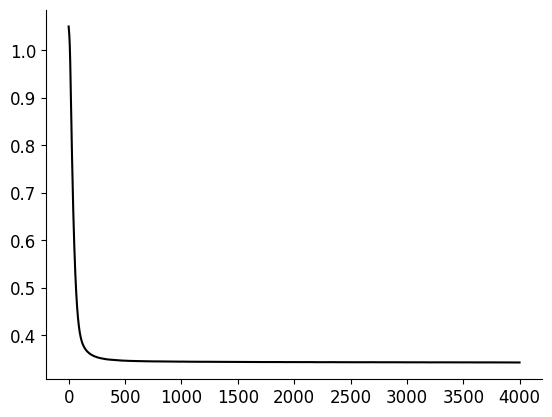

Loss: 0.33487855240280223 : 100%|██████████| 4000/4000 [05:16<00:00, 12.65it/s]


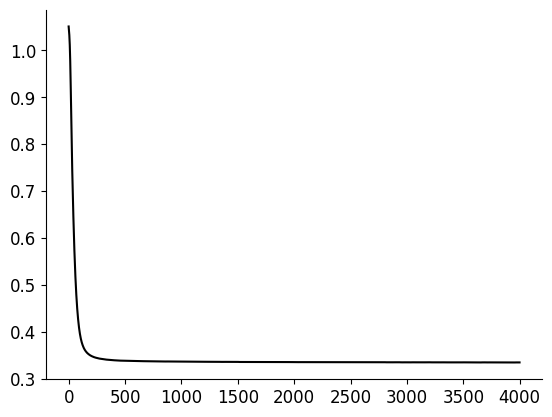

Loss: 0.32683872708732387 : 100%|██████████| 4000/4000 [06:17<00:00, 10.59it/s]


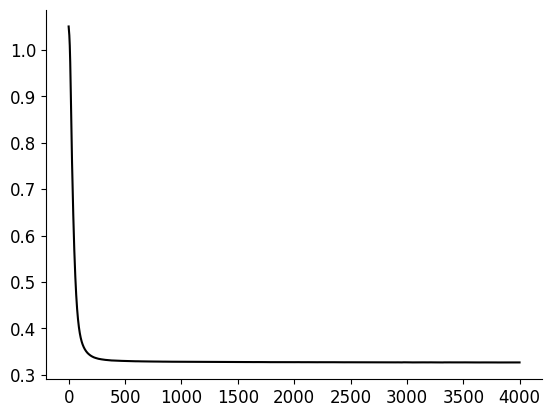

Loss: 0.319039956575396 : 100%|██████████| 4000/4000 [06:01<00:00, 11.08it/s]  


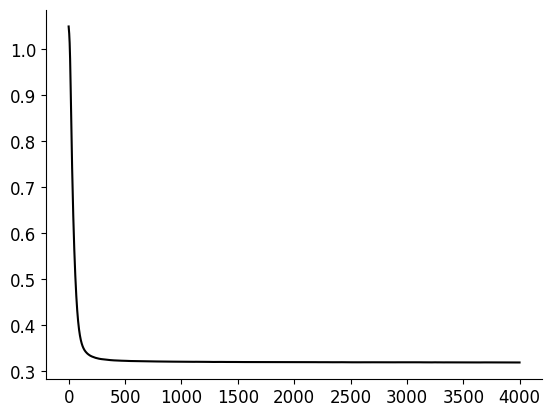

Loss: 0.31159194562563364 : 100%|██████████| 4000/4000 [05:41<00:00, 11.72it/s]


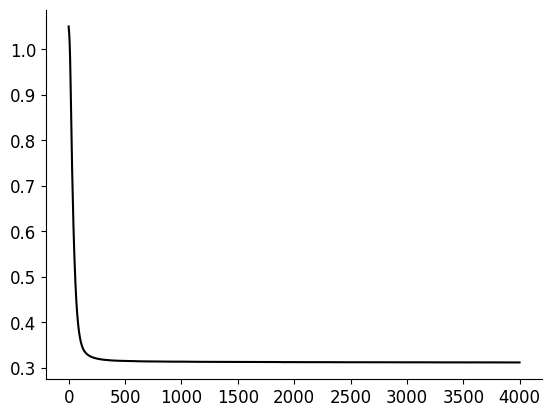

Loss: 0.30418899290106133 : 100%|██████████| 4000/4000 [05:53<00:00, 11.31it/s]


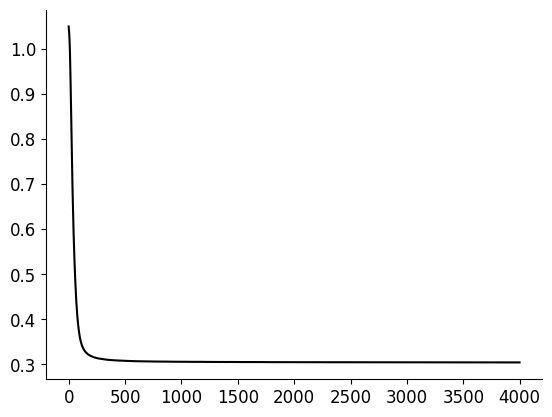

Loss: 0.29688783971251315 : 100%|██████████| 4000/4000 [04:53<00:00, 13.61it/s]


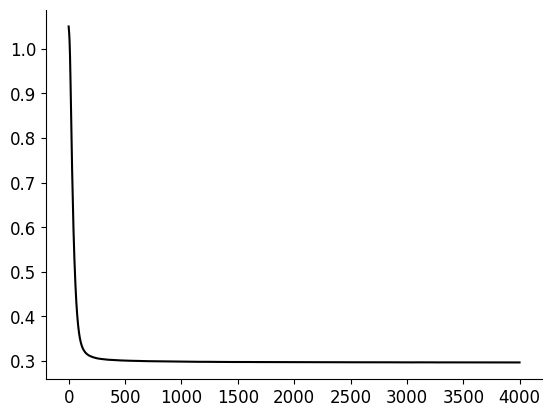

Loss: 0.2895987566104963 : 100%|██████████| 4000/4000 [04:45<00:00, 14.00it/s] 


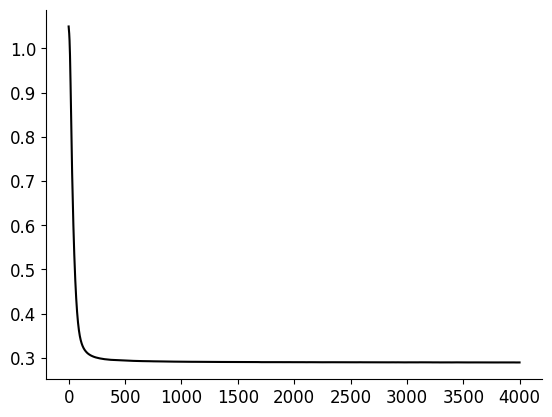

Loss: 0.28275719992127324 : 100%|██████████| 4000/4000 [05:37<00:00, 11.86it/s]


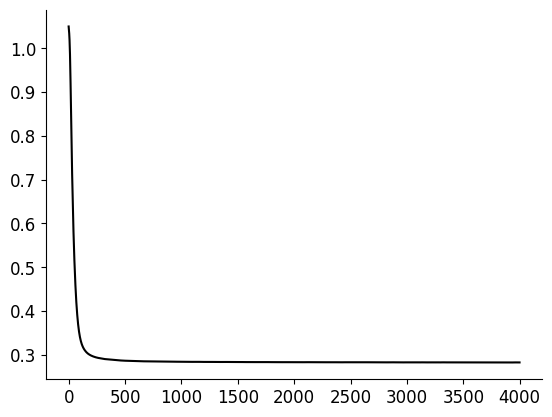

Loss: 0.27598867675324346 : 100%|██████████| 4000/4000 [06:12<00:00, 10.75it/s]


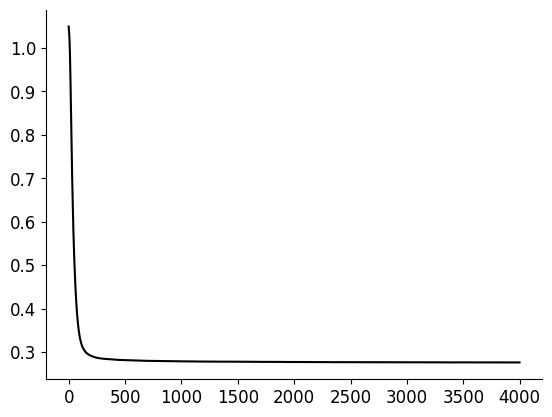

In [284]:
def get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest):
    min_val = 10000

    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data = fixed_activity_dict_NDNF_newest[animal][cell]
            if data.shape[1] < min_val:
                min_val = data.shape[1]

    data_truncated_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data_truncated = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            data_truncated_list.append(data_truncated)


    data_truncated_array = np.array(data_truncated_list)

    return data_truncated_array

def get_model_mse_dict(fixed_activity_dict_NDNF_newest, num_latents=2):
    model_and_mse_dict = {}

    data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
    example_NDNF_cell_tensor = torch.from_numpy(data_truncated_array_NDNF)
    example_NDNF_cell_tensor = example_NDNF_cell_tensor.permute(2,0,1)


    for i in range(num_latents):
        i=i+1
        
        components_10, model_10_NDNF = slicetca.decompose(example_NDNF_cell_tensor,
                                                    number_components=(0,i,0), # (trials, neurons, time bins)
                                                    positive=False,
                                                    learning_rate=1*10**-2,
                                                    min_std=10**-5,
                                                    max_iter=4000,
                                                    iter_std=1000,
                                                    seed=0)
        
        plt.plot(model_10_NDNF.losses, color='k')
        plt.show()
        reconstruction_full = model_10_NDNF.construct().numpy(force=True)
        # data_truncated_array_NDNF = np.transpose(data_truncated_array_NDNF, (2,0,1))
        MSE_val = np.mean(np.square(example_NDNF_cell_tensor.numpy(force=True)-reconstruction_full))

        model_and_mse_dict[i] = {"MSE":MSE_val,
                                "model":model_10_NDNF}
        
    return model_and_mse_dict

model_and_mse_dict_NDNF = get_model_mse_dict(fixed_activity_dict_NDNF_newest,num_latents=40)

# data_truncated_array_SST = get_truncated_to_min_data_array(activity_dict_SST)
# data_truncated_array_EC = get_truncated_to_min_data_array(activity_dict_EC)



# components_10, model_10_NDNF = slicetca.decompose(data_truncated_array_NDNF,
#                                             number_components=(0,0,10), # (trials, neurons, time bins)
#                                             positive=False,
#                                             learning_rate=1*10**-3,
#                                             min_std=10**-5,
#                                             max_iter=15_000,
#                                             seed=0)
        

In [10]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl"

with open (save_path, 'wb') as f:
    pickle.dump(model_and_mse_dict_NDNF,f)
    print(save_path)

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl


In [11]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl"

with open (save_path, 'rb') as f:
    model_and_mse_dict_NDNF = pickle.load(f)
    print(save_path)

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl


In [6]:
good_stuff.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])

Text(0.5, 1.0, 'TrialxPosition Bin Latents on All Cells Tensor')

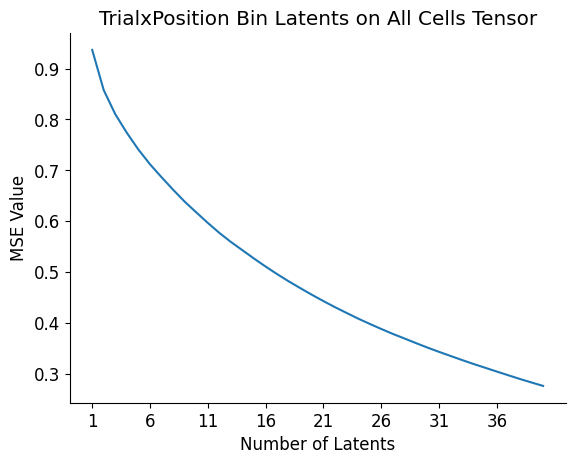

In [7]:
mse_val_list = []
for num_latents in model_and_mse_dict_NDNF:
    mse_val = model_and_mse_dict_NDNF[num_latents]["MSE"]
    mse_val_list.append(mse_val)

plt.xlabel("Number of Latents")
xvalues = np.arange(1,40+1)
plt.xticks(xvalues[::5])
plt.plot(xvalues, mse_val_list)
plt.ylabel("MSE Value")
plt.title("TrialxPosition Bin Latents on All Cells Tensor")



In [305]:
ndnf_model_20_all_cells = model_and_mse_dict_NDNF[20]["model"]
w1 = ndnf_model_20_all_cells.vectors[1][0]
f1 = ndnf_model_20_all_cells.vectors[1][1]
F = f1.detach().cpu().numpy()
W = w1.detach().cpu().numpy()
print(f"w1.shape {w1.shape} f1.shape {f1.shape}")



w1.shape torch.Size([20, 115]) f1.shape torch.Size([20, 100, 50])


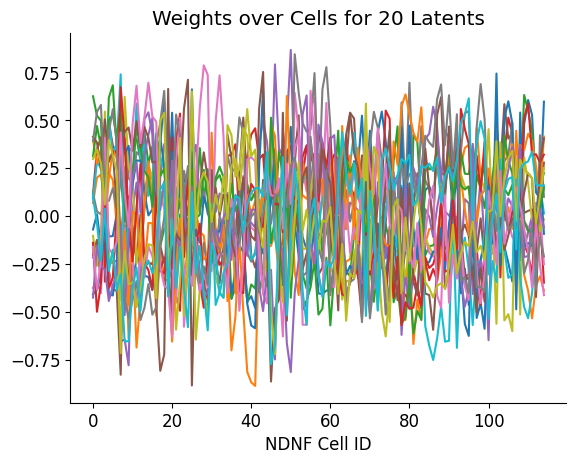

In [307]:
for i in range(W.shape[0]):
    plt.plot(W[i,:])
plt.title("Weights over Cells for 20 Latents")
plt.xlabel("NDNF Cell ID")
plt.show()

In [8]:


def get_cluster_labels(model_and_mse_dict_NDNF, num_latents:int, n_clusters:int):
    ndnf_model_20_all_cells = model_and_mse_dict_NDNF[num_latents]["model"]
    w1 = ndnf_model_20_all_cells.vectors[1][0]
    f1 = ndnf_model_20_all_cells.vectors[1][1]
    F = f1.detach().cpu().numpy()
    W = w1.detach().cpu().numpy()

    X = W.T
    labels = KMeans(n_clusters=n_clusters, n_init=100, random_state=42).fit_predict(X)
    return labels

def get_labels_all_different_Ks(model_and_mse_dict_NDNF, num_latents:int):

    labels_cells_dict_all_K = {}
    for i in range(10):
        K=i+1
        labels_cells = get_cluster_labels(model_and_mse_dict_NDNF, num_latents=num_latents, n_clusters=K)
        labels_cells_dict_all_K[K] = labels_cells


    return labels_cells_dict_all_K

labels_cells_dict_all_K_NDNF = get_labels_all_different_Ks(model_and_mse_dict_NDNF, num_latents=30)

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [9]:
synthetic_mean_array = {}
means_dict_cluster= {}
for num_clusters in labels_cells_dict_all_K_NDNF:
    data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
    # print(data_truncated_array_NDNF.shape)
    labels = labels_cells_dict_all_K_NDNF[num_clusters]
    # print(labels)
    uniq = np.unique(labels)
    real_data_mean_array = np.empty(data_truncated_array_NDNF.shape)
    mean_data_dict = {}
    mean_data_list = []
    fraction_cells_list = []
    for i in uniq:
        labels_loc = np.where(labels==i)[0]
        # print(f"labels_loc {labels_loc}")
        fraction_cells = (len(labels_loc) / real_data.shape[0])*100
        fraction_cells_list.append(fraction_cells)
        real_data_array_sliced = data_truncated_array_NDNF[labels_loc,:,:]
        # print(f"real_data_array_sliced.shape {real_data_array_sliced.shape}")
        mean_real_data_array_sliced = np.mean(real_data_array_sliced, axis=0)
        mean_data_list.append(mean_real_data_array_sliced)
        real_data_mean_array[labels_loc,:,:] = mean_real_data_array_sliced

    MSE_reco_vs_real = np.mean(np.square(data_truncated_array_NDNF-real_data_mean_array))

    mean_data_dict = {"mean_data_list":mean_data_list,
                    "fraction_cells":fraction_cells_list,
                    "MSE_reco_vs_real":MSE_reco_vs_real}
    means_dict_cluster[num_clusters] = mean_data_dict
    synthetic_mean_array[num_clusters] = real_data_mean_array



data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
data_truncated_array_NDNF_ta = np.mean(data_truncated_array_NDNF, axis=2)
fig, axs = plt.subplots(2,len(synthetic_mean_array), figsize=(30,8))
plt.suptitle("Reconstructed vs Real Trial Averaged Data")
for num_clusters in synthetic_mean_array:
    reconstructed_data = synthetic_mean_array[num_clusters]
    reconstructed_data_ta = np.mean(reconstructed_data, axis=2)
    axs[0,num_clusters-1].imshow(reconstructed_data_ta, aspect='auto')
    axs[0,num_clusters-1].set_ylabel("Cell ID")
    axs[0,num_clusters-1].set_title(f"Reconstructed K={num_clusters}")
    axs[0,num_clusters-1].set_xlabel("Position Bin")
    axs[1,num_clusters-1].imshow(data_truncated_array_NDNF_ta, aspect='auto')
    axs[1,num_clusters-1].set_title("Real T.A. Data")
    axs[1,num_clusters-1].set_xlabel("Position Bin")
plt.tight_layout()
plt.show()





NameError: name 'get_truncated_to_min_data_array' is not defined

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, normalize

def get_cell_features(w1, f1, *,
                      feature_mode="latent_pos_flat",  # "latent_pos_flat" | "latent_trials_flat" | "loadings" | "pos_profile"
                      n_cells_expected=None,
                      n_latents_expected=None):
    """
    Build per-cell feature matrix X (rows=cells).
    Handles arbitrary axis orders from SliceTCA outputs across (x00, 0x0, 00x).
    w1, f1 are torch tensors from model.vectors[which_vectors].

    feature_mode:
      - "latent_pos_flat":   (cells, latents*pos)        e.g., (115, 20*50)
      - "latent_trials_flat":(cells, latents*trials)     e.g., (115, 20*100)
      - "loadings":          (cells, latents)            e.g., (115, 20)
      - "pos_profile":       (cells, pos) via weighted latent templates

    Notes:
      • If a chosen mode can’t be formed from the available axes, it raises a helpful error.
      • Pass n_cells_expected=115 (and n_latents_expected=20) to make detection strict.
    """
    # to numpy
    W = w1.detach().cpu().numpy()
    F = f1.detach().cpu().numpy()

    # small helpers
    def find_axis_by_size(shape, target):
        return shape.index(target) if (target in shape) else None

    def move_front(a, ax):
        return np.moveaxis(a, ax, 0)

    # Try to detect latents axis (often 20)
    Lw = find_axis_by_size(W.shape, n_latents_expected) if n_latents_expected else None
    Lf = find_axis_by_size(F.shape, n_latents_expected) if n_latents_expected else None
    # Detect cells axis (often 115)
    Cw = find_axis_by_size(W.shape, n_cells_expected) if n_cells_expected else None
    Cf = find_axis_by_size(F.shape, n_cells_expected) if n_cells_expected else None

    # ---- Option 1: LOADINGS (cells × latents) ----
    if feature_mode == "loadings":
        # Prefer a (latents, cells) slice if present (W or F that directly has cells)
        if (Lw is not None) and (Cw is not None) and W.ndim == 2:
            # W (latents, cells) -> (cells, latents)
            X = np.moveaxis(W, (Lw, Cw), (1, 0))
            X = X.T  # (cells, latents)
            return X
        # Else try from F by reducing non-latent dims
        if Cf is not None and Lf is not None and F.ndim >= 2:
            # bring cells front, latents second
            order = [Cf, Lf] + [ax for ax in range(F.ndim) if ax not in (Cf, Lf)]
            G = np.transpose(F, order)     # (cells, latents, ...)
            if G.ndim == 2:
                return G  # already (cells, latents)
            # average remaining dims (e.g., trials/pos) → (cells, latents)
            X = G.mean(axis=tuple(range(2, G.ndim)))
            return X
        raise ValueError("Cannot form 'loadings': no (latents,cells) pairing found in W/F.")

    # ---- Option 2: latent × pos flattened (cells × (L*P)) ----
    if feature_mode == "latent_pos_flat":
        # We need a tensor that contains (latents, cells, pos) in some order
        # Check F first (most common)
        if Cf is not None and Lf is not None and 3 <= F.ndim <= 4:
            # find a pos-like axis: pick the remaining non-cells, non-latents axis
            rem = [ax for ax in range(F.ndim) if ax not in (Cf, Lf)]
            if not rem:
                raise ValueError("No pos axis found in F for latent_pos_flat.")
            pos_ax = rem[0]
            # reorder to (cells, latents, pos, [maybe ...])
            order = [Cf, Lf, pos_ax] + [ax for ax in rem[1:]]
            G = np.transpose(F, order)
            # if more dims exist, mean over them
            if G.ndim > 3:
                G = G.mean(axis=tuple(range(3, G.ndim)))
            C, L, P = G.shape
            X = G.reshape(C, L * P)
            return X
        # Else: if W has (latents, pos) and *no* cells, we can’t build per-cell features from W alone.
        raise ValueError("Cannot form 'latent_pos_flat' from current W/F: need latents+cells+pos together (usually in F).")

    # ---- Option 3: latent × trials flattened (cells × (L*T)) ----
    if feature_mode == "latent_trials_flat":
        # Need (latents, trials, cells) in some order
        if Cf is not None and Lf is not None and 3 <= F.ndim <= 4:
            rem = [ax for ax in range(F.ndim) if ax not in (Cf, Lf)]
            if not rem:
                raise ValueError("No trials axis found in F for latent_trials_flat.")
            tr_ax = rem[0]
            order = [Cf, Lf, tr_ax] + [ax for ax in rem[1:]]
            G = np.transpose(F, order)  # (cells, latents, trials, [maybe ...])
            if G.ndim > 3:
                G = G.mean(axis=tuple(range(3, G.ndim)))
            C, L, T = G.shape
            X = G.reshape(C, L * T)
            return X
        raise ValueError("Cannot form 'latent_trials_flat': need latents+cells+trials together (usually in F).")

    # ---- Option 4: pos_profile (cells × pos), via weighted templates if possible ----
    if feature_mode == "pos_profile":
        # If we have (latents,cells, pos) in F: average latents → (cells, pos)
        if Cf is not None and Lf is not None and 3 <= F.ndim:
            rem = [ax for ax in range(F.ndim) if ax not in (Cf, Lf)]
            pos_ax = rem[0] if rem else None
            if pos_ax is not None:
                order = [Cf, Lf, pos_ax] + [ax for ax in rem[1:]]
                G = np.transpose(F, order)  # (cells, latents, pos, ...)
                if G.ndim > 3:
                    G = G.mean(axis=tuple(range(3, G.ndim)))
                X = G.mean(axis=1)  # avg over latents -> (cells, pos)
                return X
        raise ValueError("Cannot form 'pos_profile' from current W/F.")

    raise ValueError(f"Unknown feature_mode: {feature_mode}")


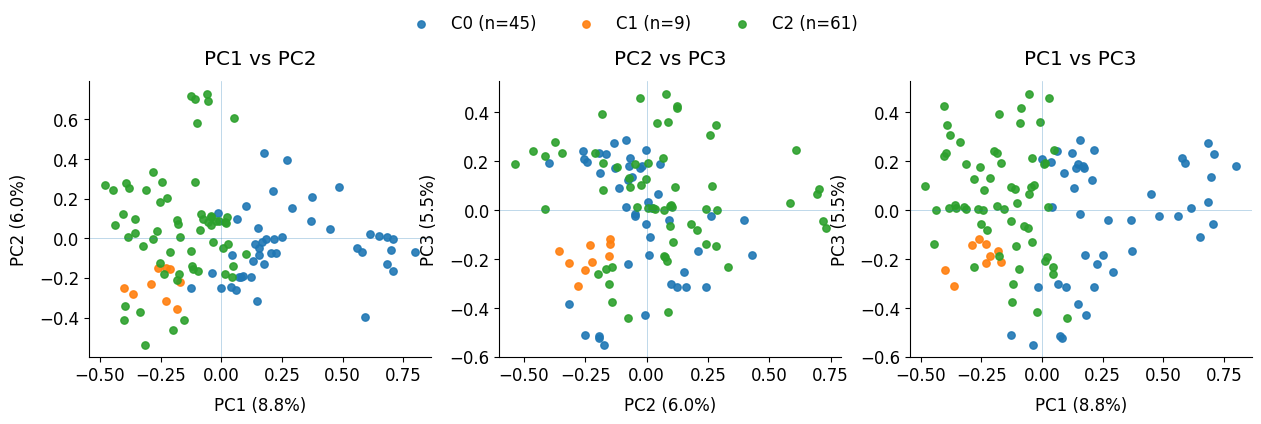

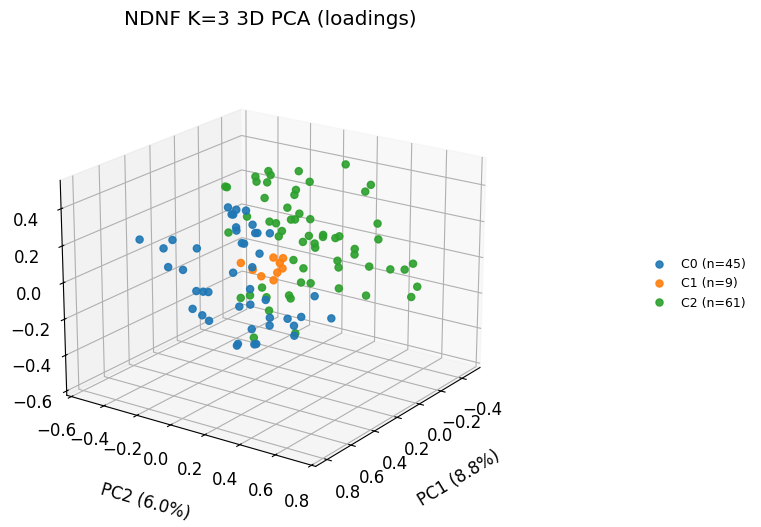

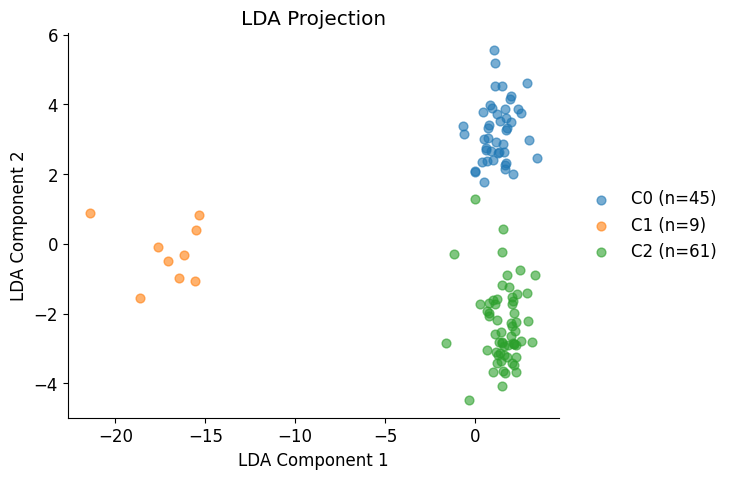

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def pca_cluster_viz_triptych(w1, f1, labels, feature_space="loadings", feature_mode=None, n_cells_expected=None, n_latents_expected=None, n_components=3, title_prefix=""):
    labels = np.asarray(labels)

    # === features & PCA (reuse your helpers/steps) ===
    # X = get_cell_features(w1, f1, feature_space=feature_space)

    get_cell_features(w1, f1,
                      feature_mode=feature_mode,  # "latent_pos_flat" | "latent_trials_flat" | "loadings" | "pos_profile"
                      n_cells_expected=n_cells_expected,
                      n_latents_expected=n_latents_expected)


    from sklearn.preprocessing import StandardScaler, normalize
    from sklearn.decomposition import PCA
    Xn = normalize(StandardScaler().fit_transform(X), norm="l2", axis=1)

    n_components = min(n_components, Xn.shape[1])
    if n_components < 3:
        raise ValueError(f"Need at least 3 PCs; got n_components={n_components}")
    pca = PCA(n_components=n_components, random_state=42)
    Z = pca.fit_transform(Xn)                   # (cells, n_components)
    evr = pca.explained_variance_ratio_         # len >= 3

    uniq = np.unique(labels)

    # === three subplots: (PC1,PC2), (PC2,PC3), (PC1,PC3) ===
    pairs = [(0,1), (1,2), (0,2)]
    fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)

    handles = []
    for ax, (i, j) in zip(axs, pairs):
        for lab in uniq:
            m = labels == lab
            ax.scatter(Z[m, i], Z[m, j], s=28, alpha=0.9, label=f"C{lab} (n={m.sum()})")
        ax.set_xlabel(f"PC{i+1} ({evr[i]*100:.1f}%)", labelpad=8)   # <—
        ax.set_ylabel(f"PC{j+1} ({evr[j]*100:.1f}%)", labelpad=8)   # <—
        ax.set_title(f"PC{i+1} vs PC{j+1}", pad=12)                 # <—
        ax.axhline(0, lw=0.5, alpha=0.4)
        ax.axvline(0, lw=0.5, alpha=0.4)

    # single legend outside (avoid duplicates)
    # grab handles/labels from the last axis
    handles, labels_txt = axs[-1].get_legend_handles_labels()
    fig.legend(handles, labels_txt, loc="upper center", ncol=min(len(uniq), 6), frameon=False)
    # fig.suptitle(f"{title_prefix} PCA ({feature_space})", y=1.06, fontsize=12)

    fig.subplots_adjust(top=0.80)
    
    
    
    from mpl_toolkits.mplot3d import Axes3D  # noqa

    fig3d = plt.figure(figsize=(8, 6))  # a bit larger helps

    ax3d  = fig3d.add_subplot(111, projection='3d')

    # --- scatter ---
    for lab in uniq:
        m = labels == lab
        ax3d.scatter(Z[m,0], Z[m,1], Z[m,2], s=26, alpha=0.9, label=f"C{lab} (n={m.sum()})")

    # --- axis labels/title with extra padding ---
    ax3d.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)", labelpad=18)
    ax3d.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)", labelpad=18)
    ax3d.set_zlabel(f"PC3 ({evr[2]*100:.1f}%)", labelpad=18)
    ax3d.set_title(f"{title_prefix} 3D PCA ({feature_space})", pad=18)

    ax3d.tick_params(pad=6)  # space between ticks and tick labels

    ax3d.legend(loc="center left", bbox_to_anchor=(1.28, 0.5), frameon=False, fontsize=9)

    fig3d.subplots_adjust(left=0.08, right=0.72, bottom=0.10, top=0.88)

    ax3d.view_init(elev=20, azim=35)

    plt.show()

    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

    lda = LinearDiscriminantAnalysis(n_components=2)
    X_lda = lda.fit_transform(X, labels)

    uniq = np.unique(labels)

    fig, ax = plt.subplots(figsize=(7.5, 5))  # a bit wider helps
    for k in uniq:
        m = labels == k
        ax.scatter(X_lda[m, 0], X_lda[m, 1],
                s=40, alpha=0.6, label=f"C{k} (n={m.sum()})")

    ax.set_xlabel("LDA Component 1")
    ax.set_ylabel("LDA Component 2")
    ax.set_title("LDA Projection")

    leg = ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
                    frameon=False, ncol=1)

    fig.subplots_adjust(right=0.78)   # tweak to taste (smaller -> more space)

    plt.show()





num_latents=30
# ndnf_model_20_all_cells = model_20_NDNF_resid

ndnf_model_20_all_cells = model_and_mse_dict_NDNF[num_latents]["model"]
w1 = ndnf_model_20_all_cells.vectors[1][0]
f1 = ndnf_model_20_all_cells.vectors[1][1]

num_clusters=3


labels_cells_dict_all_K_NDNF = get_labels_all_different_Ks(model_and_mse_dict_NDNF, num_latents=num_latents)

pca_cluster_viz_triptych(w1, f1, labels_cells_dict_all_K_NDNF[num_clusters], feature_space="loadings", title_prefix=f"NDNF K={num_clusters}")

"latent_pos_flat" | "latent_trials_flat" | "loadings" | "pos_profile"

      - "latent_pos_flat":   (cells, latents*pos)        e.g., (115, 20*50)
      - "latent_trials_flat":(cells, latents*trials)     e.g., (115, 20*100)
      - "loadings":          (cells, latents)            e.g., (115, 20)


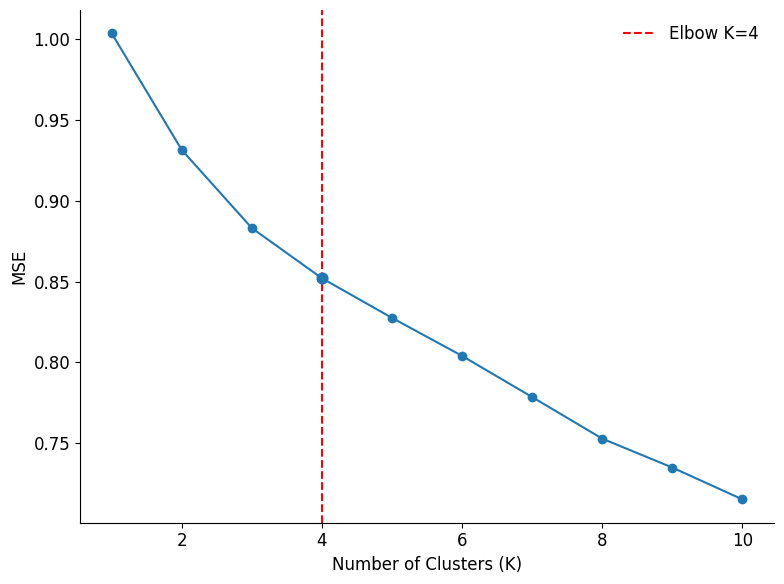

Elbow K: 4


In [382]:
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator

# Build x=K (sorted) and y=MSE arrays
Ks, MSEs = zip(*sorted(((int(K), means_dict_cluster[K]["MSE_reco_vs_real"]) for K in means_dict_cluster),key=lambda kv: kv[0]))
Ks   = np.array(Ks)
MSEs = np.array(MSEs, dtype=float)

if MSEs.size >= 3:
    pad = np.r_[MSEs[0], MSEs, MSEs[-1]]
    MSEs_smooth = np.convolve(pad, np.ones(3)/3, mode='valid')
else:
    MSEs_smooth = MSEs

kneedle = KneeLocator(Ks, MSEs_smooth,curve="convex", direction="decreasing", S=1.0)

elbow_K = kneedle.knee  

plt.figure(figsize=(8,6))
plt.plot(Ks, MSEs, marker="o")
if elbow_K is not None:
    plt.axvline(elbow_K, linestyle="--", label=f"Elbow K={elbow_K}", color='r')
    # Mark the point closest to elbow_K
    elbow_idx = int(np.argmin(np.abs(Ks - elbow_K)))
    plt.scatter([Ks[elbow_idx]], [MSEs[elbow_idx]], s=60, zorder=3)
else:
    # Fallback: choose K at max drop in MSE (first difference)
    if len(Ks) > 1:
        diffs = np.diff(MSEs)
        elbow_idx = int(np.argmin(diffs)) + 1  # +1 → right side of steepest drop
        elbow_K = Ks[elbow_idx]
        plt.axvline(elbow_K, linestyle="--", label=f"Fallback K={elbow_K}")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("MSE")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Elbow K:", elbow_K)




In [360]:
len(labels_cells_dict_all_K_NDNF[4])

115

data_trunc.shape (79, 50, 100)
data_trunc.shape (6, 50, 100)
data_trunc.shape (9, 50, 100)
data_trunc.shape (15, 50, 100)
data_trunc.shape (6, 50, 100)


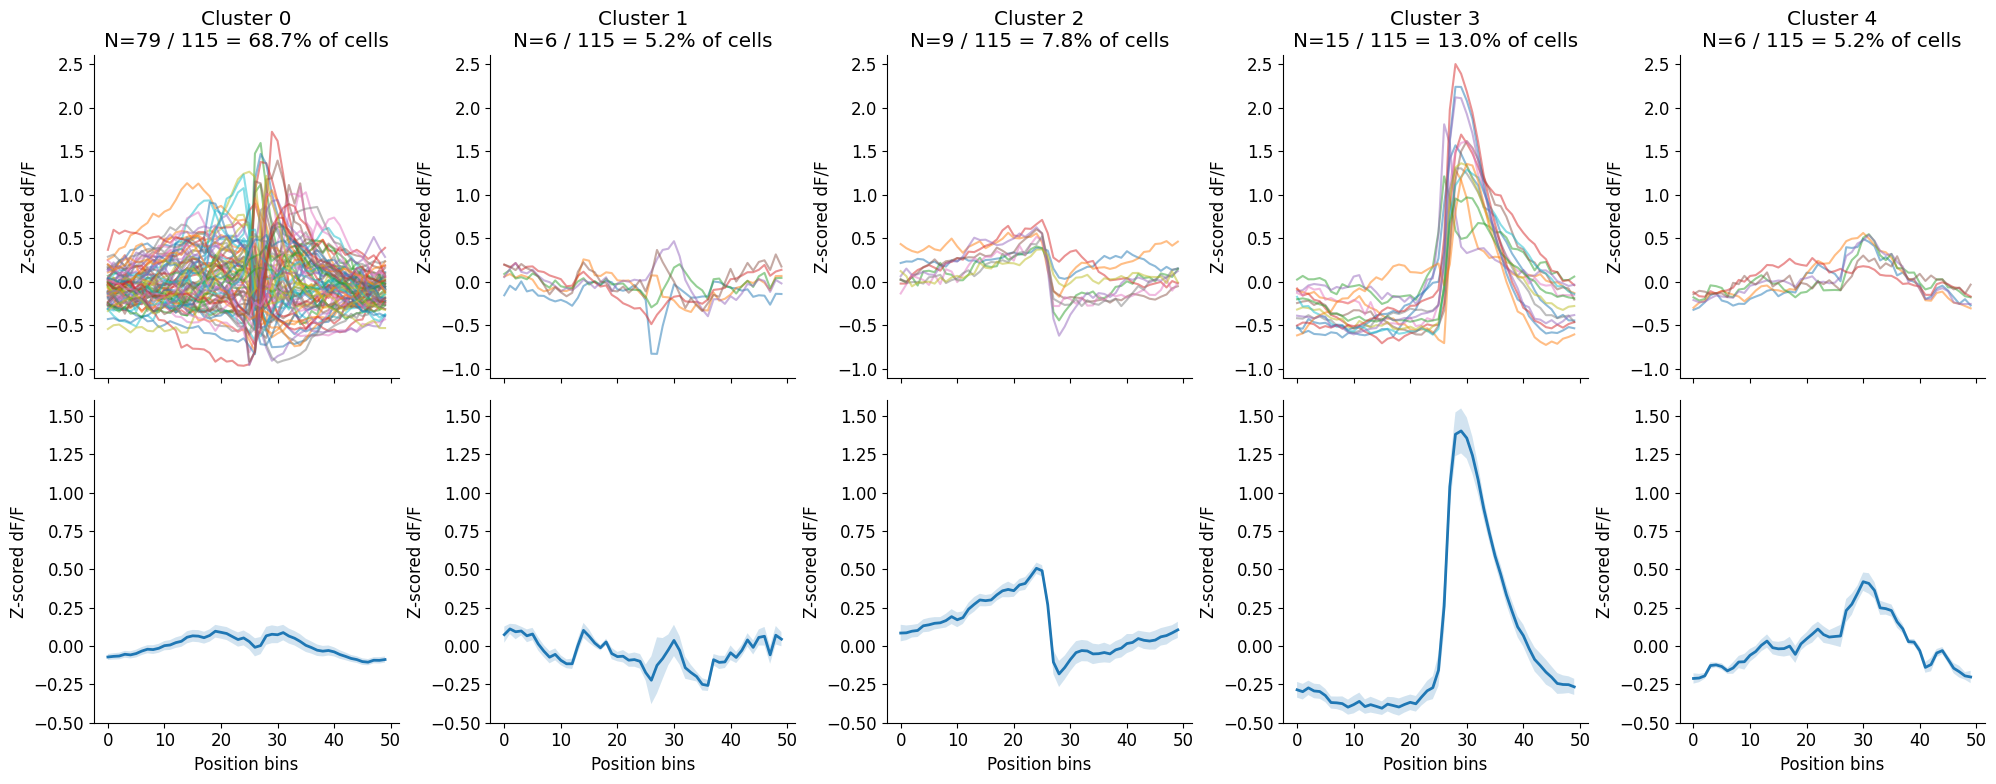

In [432]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

def plot_per_cell_clustering(labels_cells_dict_all_K_NDNF, fixed_activity_dict_NDNF_newest, num_clusters: int):
    labels_4_clust = np.asarray(labels_cells_dict_all_K_NDNF[num_clusters])
    uniq = np.unique(labels_4_clust)

    # data: expect (cells, pos, trials); move/choose axis if needed
    data = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
  
    n_cells, n_pos, n_trials = data.shape

    separated_data_dict = {}
    separated_data_dict_ta = {}
    count_dict = {}
    total_count = 0

    label_to_col = {lab: j for j, lab in enumerate(uniq)}

    for lab in uniq:
        labels_loc = np.where(labels_4_clust == lab)[0]
        data_trunc = data[labels_loc, :, :]                 # (n_k, n_pos, n_trials)
        print(f"data_trunc.shape {data_trunc.shape}")
        separated_data_dict[lab] = data_trunc
        separated_data_dict_ta[lab] = np.mean(data_trunc, axis=2)  # (n_k, n_pos)
        count_dict[lab] = len(labels_loc)
        total_count += len(labels_loc)

    # Sanity check: did we keep all cells?
    if total_count != n_cells:
        missing = n_cells - total_count
        print(f"[warn] {missing} cells not assigned across clusters (total {total_count}/{n_cells}={(total_count/n_cells)*100}%).")

    # Plot
    C = len(separated_data_dict_ta)
    fig, axs = plt.subplots(2, C, figsize=(4*C, 8), sharex=True)
    if C == 1:  # keep indexing consistent
        axs = np.array(axs).reshape(2, 1)

    for lab, clust_data in separated_data_dict_ta.items():
        col = label_to_col[lab]
        mean_clust = clust_data.mean(axis=0)           
        sem_clust  = sem(clust_data, axis=0)          

        for i in range(clust_data.shape[0]):
            axs[0, col].plot(clust_data[i, :], alpha=0.5)

        axs[1, col].plot(mean_clust, lw=2)
        axs[1, col].fill_between(np.arange(n_pos), mean_clust - sem_clust, mean_clust + sem_clust, alpha=0.2)

        axs[0, col].set_title(f"Cluster {lab}\nN={count_dict[lab]} / {total_count} = {(count_dict[lab]/total_count)*100:.1f}% of cells")
        axs[0, col].set_ylabel("Z-scored dF/F")
        axs[1, col].set_ylabel("Z-scored dF/F")
        axs[1, col].set_xlabel("Position bins")

        axs[0, col].set_ylim(-1.1, 2.6)
        axs[1, col].set_ylim(-0.5, 1.6)

    plt.tight_layout()
    plt.show()

# plot_per_cell_clustering(labels_cells_dict_all_K_NDNF, num_clusters=6)
plot_per_cell_clustering(labels_cells_dict_all_K_NDNF_single, fixed_residual_activity_dict_NDNF_newest, num_clusters=5)


# def plot_per_cell_clustering(labels_cells_dict_all_K_NDNF, num_clusters:int):
#     labels_4_clust = labels_cells_dict_all_K_NDNF[num_clusters]
#     uniq = np.unique(labels_4_clust)
#     data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
#     seperated_data_dict = {}
#     seperated_data_dict_ta = {}
#     count_dict = {}
#     total_count = 0
#     for i in uniq:
#         labels_loc = np.where(labels==i)[0]
#         data_trunc = data_truncated_array_NDNF[labels_loc,:,:]
#         print(f"data_trunc.shape {data_trunc.shape}")
#         seperated_data_dict[i] = data_trunc
#         seperated_data_dict_ta[i] = np.mean(data_trunc, axis=2)
#         count_dict[i] = len(labels_loc)
#         total_count+= len(labels_loc)


#     fig, axs = plt.subplots(2,len(seperated_data_dict_ta), figsize=(20,8))
#     for clust in seperated_data_dict_ta:
#         clust_data = seperated_data_dict_ta[clust]
#         mean_clust = np.mean(clust_data, axis=0)
#         sem_clust = sem(clust_data, axis=0)
#         for i in range(clust_data.shape[0]):
#             axs[0,clust].plot(clust_data[i,:])
#         axs[0,clust].set_ylim(-1.1, 2.6)
#         axs[1,clust].set_ylim(-0.4, 1.2)
#         axs[1,clust].plot(mean_clust)
#         axs[0,clust].set_title(f"Cluster {clust} \n N={count_dict[clust]} / {total_count} Cells")
#         axs[0,clust].set_ylabel("Z-Scored DF/F")
#         axs[1,clust].set_ylabel("Z-Scored DF/F")
#         axs[0,clust].set_xlabel("Position Bins")
#         axs[1,clust].set_xlabel("Position Bins")
#         axs[1,clust].fill_between(range(len(mean_clust)), mean_clust-sem_clust, mean_clust+sem_clust, alpha=0.2)

#     plt.tight_layout()
#     plt.show()
        

# plot_per_cell_clustering(labels_cells_dict_all_K_NDNF, num_clusters=4)

In [ ]:
MSE_dict_per_animal = {} 

for num_clusters in real_data_mean_array_animal_dict_clusters:
    MSE_list_per_animal = []
    for animal in real_data_mean_array_animal_dict_clusters[num_clusters]:
        real_data_tensor = real_data_dict[animal]
        reco_data_tensor = real_data_mean_array_animal_dict_clusters[num_clusters][animal]
        MSE = np.mean(np.square(real_data_tensor-reco_data_tensor))
        MSE_list_per_animal.append(MSE)
    MSE_dict_per_animal[num_clusters] = MSE_list_per_animal


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

Ks = sorted(MSE_dict_per_animal.keys())
vals = [np.asarray(MSE_dict_per_animal[K], dtype=float) for K in Ks]

means = np.array([v.mean() if v.size else np.nan for v in vals])
sems  = np.array([sem(v, ddof=1) if v.size > 1 else np.nan for v in vals])

plt.figure(figsize=(7,4))
plt.errorbar(Ks, means, yerr=sems, fmt='-o', capsize=3)
plt.xlabel("Number of clusters (K)")
plt.ylabel("MSE (mean ± SEM across animals)")
plt.title("Reconstruction Error vs Num Clusters")
plt.tight_layout()
plt.show()

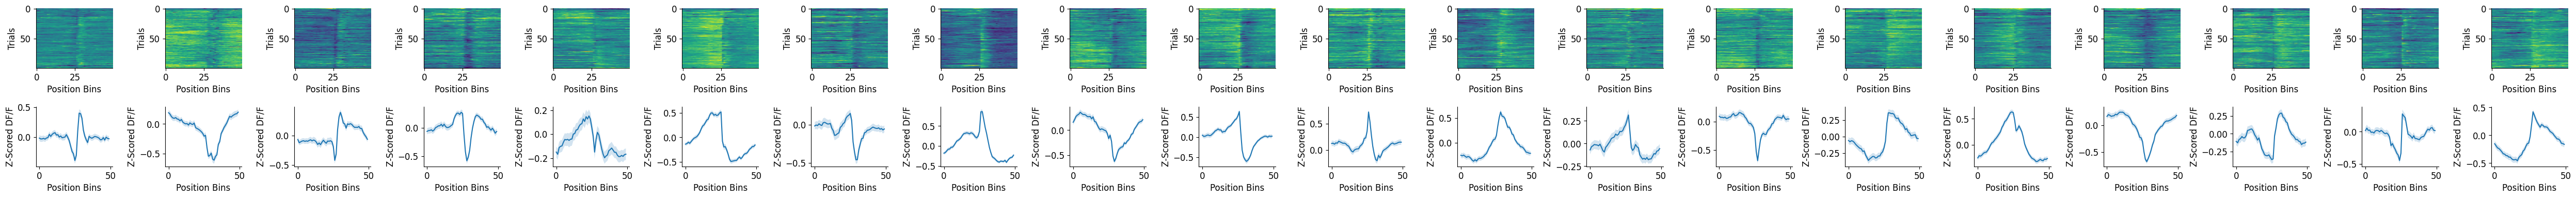

In [304]:
########plotting all latent factors 

fig, axs = plt.subplots(2, F.shape[0], figsize=(50,4))

for i in range(F.shape[0]):
    latent_factor = F[i,:,:]
    mean_latent_factor = np.mean(latent_factor, axis=0)
    sem_latent_factor = sem(latent_factor, axis=0)
    axs[0,i].imshow(latent_factor, aspect="auto")
    axs[0,i].set_xlabel("Position Bins")
    axs[0,i].set_ylabel("Trials")
    axs[0,i].imshow(latent_factor, aspect="auto")
    axs[1,i].plot(mean_latent_factor)
    axs[1,i].fill_between(range(len(mean_latent_factor)), mean_latent_factor-sem_latent_factor, mean_latent_factor+sem_latent_factor, alpha=0.2)
    axs[1,i].set_ylabel("Z-Scored DF/F")
    axs[1,i].set_xlabel("Position Bins")
plt.tight_layout()
plt.show()





In [ ]:
def get_cluster_labels(models_dict, use_pca=False, pca_dims=None, n_clusters=None):
    labels_cells_dict = {}
    for idx, model_name in enumerate(models_dict):
        model = models_dict[model_name]
        w1 = model.vectors[2][0]
        f1 = model.vectors[2][1]

        print(f"w1.shape {w1.shape} f1.shape {f1.shape}")

        F = f1.detach().cpu().numpy()
        X = np.moveaxis(F, 2, 0)              # X: (cells=7, latents=10, feats=107)
        X = X.reshape(X.shape[0], -1)         # X: (7, 10*107)

        # z-score features across cells (critical given tiny N)
        # Xz = StandardScaler(with_mean=True, with_std=True).fit_transform(X)

        if use_pca:
            Xp = PCA(n_components=6, random_state=0).fit_transform(X)


            labels_cells = KMeans(n_clusters=n_clusters, n_init=100, random_state=0).fit_predict(Xp)
            labels_cells_dict[model_name] = labels_cells

        else:
            labels_cells = KMeans(n_clusters=n_clusters, n_init=100, random_state=0).fit_predict(X)
            labels_cells_dict[model_name] = labels_cells
            print("cell labels:", labels_cells)

    return labels_cells_dict

In [287]:
save_path='/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/all_NDNF_mse_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_and_mse_dict_NDNF, f)
    print(f"saved to {save_path}")

saved to /Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/all_NDNF_mse_model.pkl


In [278]:
model_to_test = model_and_mse_dict_NDNF[4]['model']
reconstruction_full = model_10_NDNF.construct().numpy(force=True)
reconstruction_full.shape

(100, 115, 50)

Text(0.5, 1.0, 'Trough Loc > Pos Bin 35')

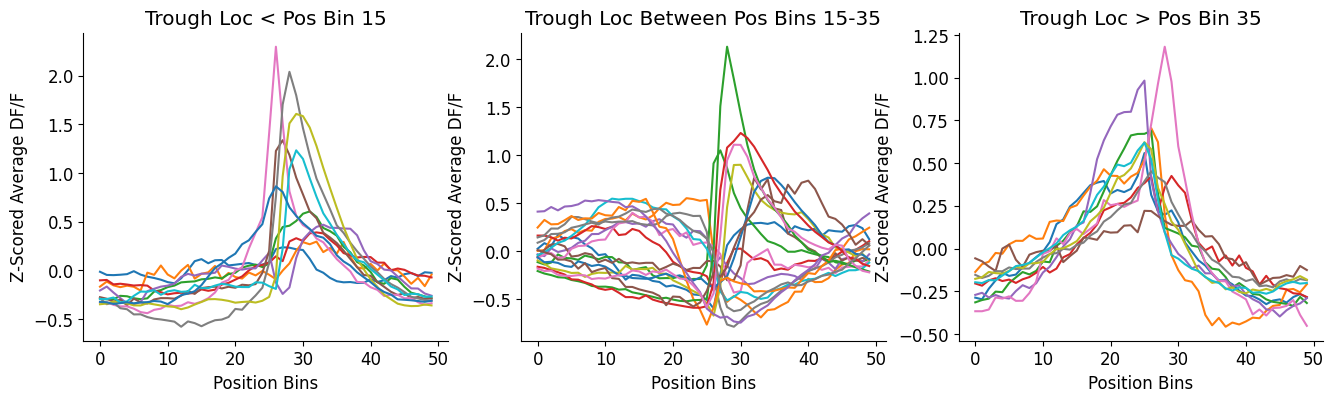

In [ ]:
trough_loc_list = []
peak_loc_list = []

before_reward = []
near_reward = []
after_reward = []

for animal in mean_cluster_dict_per_animal:
    for cluster_id in mean_cluster_dict_per_animal[animal]:
        data = mean_cluster_dict_per_animal[animal][cluster_id]
        troughloc = np.argmin(data)
        trough_loc_list.append(troughloc)
        peakloc = np.argmax(data)
        peak_loc_list.append(peakloc)
        if troughloc <=15:
            before_reward.append(data)
        elif 15 < troughloc <35:
            near_reward.append(data)
        elif troughloc >=35:
            after_reward.append(data)



fig, axs = plt.subplots(1,3, figsize=(16,4))

for i in range(len(before_reward)):
    axs[0].plot(before_reward[i])
axs[0].set_ylabel("Z-Scored Average DF/F")
axs[0].set_xlabel("Position Bins")
axs[0].set_title("Trough Loc < Pos Bin 15")

for i in range(len(near_reward)):
    axs[1].plot(near_reward[i])
axs[1].set_ylabel("Z-Scored Average DF/F")
axs[1].set_xlabel("Position Bins")
axs[1].set_title("Trough Loc Between Pos Bins 15-35")

for i in range(len(after_reward)):
    axs[2].plot(after_reward[i])
axs[2].set_ylabel("Z-Scored Average DF/F")
axs[2].set_xlabel("Position Bins")
axs[2].set_title("Trough Loc > Pos Bin 35")

In [ ]:

def get_animals_models(fixed_activity_dict_NDNF_newest, animal):
    models_list = []

    for cell in fixed_activity_dict_NDNF_newest[animal]:

        example_NDNF_cell = fixed_activity_dict_NDNF_newest[animal][cell]

        example_NDNF_cell_tensor = torch.from_numpy(example_NDNF_cell).unsqueeze(axis=1)
        example_NDNF_cell_tensor = example_NDNF_cell_tensor.permute(2, 1, 0)
        print(example_NDNF_cell_tensor.shape)  # should now be torch.Size([78, 1, 50])

        components_10, model_10_NDNF = slicetca.decompose(example_NDNF_cell_tensor,
                                            number_components=(0,0,10), # (trials, neurons, time bins)
                                            positive=False,
                                            learning_rate=1*10**-3,
                                            min_std=10**-5,
                                            max_iter=15_000,
                                            seed=0)
        
        models_list.append(model_10_NDNF)
    return models_list


models_dict_per_animal = {}
for animal in fixed_activity_dict_NDNF_newest:
    models_list_animal = get_animals_models(fixed_activity_dict_NDNF_newest, animal)
    models_dict_per_animal[animal] = models_list_animal



